<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/3.0%20Customer%20Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#!pip install s3fs

### 1.0 INTRODUCTION
The primary objective of this notebook, is training of a `customer segmentation model`, using the `KMeans` unsupervised machine learning algorithm; to identify patterns, and accordingly group customers based on shared characteristics in their first 60 days tenure with the business; overcoming the default to treat every customer the same.

The model is stored as a joblib file, allowing for new datasets with the exact features, to be segmented in deployment, as well as for other exploratory data analysis purposes. The customer segmentation personas, in later notebooks, will be included as a feature, to hint the churn, and revenue predictive models to treat these customers differently.

In [4]:

import sys
import os
import importlib
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, inspect, text
from google.colab import userdata

from datetime import datetime

bucket_name = 'sales-data-analytics-portfolio-2026'

os.environ["AWS_SECRET_ACCESS_KEY"] = userdata.get("AWS_SECRET_ACCESS_KEY")
os.environ["AWS_ACCESS_KEY_ID"] = userdata.get("AWS_ACCESS_KEY_ID")
os.environ["AWS_DEFAULT_REGION"] = "eu-north-1"

parquet_url = "s3://sales-data-analytics-portfolio-2026/parquet_files/fact_online_retail_clean.parquet"

cutoff_date = '2011-08-31'

df = pd.read_parquet(parquet_url)


df = df[df["InvoiceDate"].dt.date.astype('str') <= cutoff_date]
df.info()
print("\nPreview of data exported from AWS S3 datalake")
print()
df.sort_values("InvoiceDate").head()

<class 'pandas.core.frame.DataFrame'>
Index: 225578 entries, 0 to 225577
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    225578 non-null  object        
 1   StockCode    225578 non-null  object        
 2   Description  225578 non-null  object        
 3   Quantity     225578 non-null  int64         
 4   InvoiceDate  225578 non-null  datetime64[ns]
 5   UnitPrice    225578 non-null  float64       
 6   CustomerID   225578 non-null  float64       
 7   Country      225578 non-null  object        
 8   Revenue      225578 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 17.2+ MB

Preview of data exported from AWS S3 datalake



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


#### 1.10 Feature Engineering
To meet the objective of this notebook, every customer's `FirstPurchase` was extracted; and a total of `60 days` was added to their `FirstPurchase`. The dataset was filtered accordingly, retaining every client's transactions within the `first 60 days`. Thereafter, the `feature_engineering` function, created in the feature engineering notebook, and stored in S3, was streamed from AWS S3 and applied to the dataset.

To analyze `Customer Churn`, a total of `100 days` was added to every customers 60-day customer tenure date, creating a separate dataframe with customer `Frequency` after 60 days within the next 100 days. This was to get a picture of what proportion of each segment, `did not shop within 100 days after clocking a 60 day Tenure`. Having capped the data to a `first 60-day` observation window, implies every client's tenure is 60 days at point of analysis; accordingly all features calculated using `Tenure` and `Recency` were dropped.

It should however be noted, that the tenure of focus, and churn window, are dynamic, and can be altered, but were nevertheless selected following prior exploratory data analysis, which focused on `InterPurchaseInterval Intervals` and `Cohort Retention Matrix Analysis`.

In [5]:
import s3fs

fs = s3fs.S3FileSystem()
function_url = "s3://sales-data-analytics-portfolio-2026/functions/feature_engineering.py"

with fs.open(function_url, "r") as file:
    exec(file.read())


from datetime import timedelta
data = df.groupby("CustomerID").agg(
FirstPurchase = ("InvoiceDate", "min")
).reset_index()

cutoff_days = timedelta(days = 60)
test_end_days = timedelta(days = 100)

data["Cutoff"] = data["FirstPurchase"] + cutoff_days
data["TestEnd"] = data["Cutoff"] + test_end_days


df = df.merge(data, on = "CustomerID", how = "left")

#Excluding Revenue extreme values

df = df[df["Revenue"]  < df["Revenue"].quantile(0.98)]

X_features = df[df["InvoiceDate"] <= df["Cutoff"]].copy()

# getting last purchase with first window to compute date to churn by customer
lastpurchase = X_features.groupby(["CustomerID"]).agg(LastPurchase = ("InvoiceDate", "max")).reset_index()

df = df.merge(lastpurchase, on = "CustomerID", how = 'left')

# target is pulled from their last purchase within the first 30days/cutoff, up to 100 days or test end period from that date
y_feature = df[(df["InvoiceDate"] > df["LastPurchase"]) & (df["InvoiceDate"] <= (df["LastPurchase"] + test_end_days))].copy()

X_features.drop(["FirstPurchase", "Cutoff", "TestEnd"], axis = 1, inplace = True)
y_feature.drop(["FirstPurchase", "Cutoff", "TestEnd"], axis = 1, inplace = True)


X_features = feature_engineering(X_features)
y_feature = feature_engineering(y_feature)

#Filtering Segmentation to Ensure Each client had the chance to shop with in exactly 60 from first purchase
X_features = X_features[X_features['Tenure'] >= 60]

after_cutoff = pd.DataFrame(X_features["CustomerID"]).merge(y_feature, how = 'left', on = "CustomerID")

features = X_features.fillna(0)

X = features.drop(["CustomerID", "CohortMonth", "Recency", "Tenure", "RecencyToTenure", "LifetimePurchaseDensity","LifetimeMRate","RelativeSilence"], axis = 1)

X.info()
print()
X.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2900 entries, 0 to 3236
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Frequency              2900 non-null   int64  
 1   ProductDiversity       2900 non-null   int64  
 2   AvgUnitPrice           2900 non-null   float64
 3   AvgQuantity            2900 non-null   float64
 4   AOV                    2900 non-null   float64
 5   TotalRevenue           2900 non-null   float64
 6   ObservedLifeSpan       2900 non-null   int64  
 7   ActivePurchaseDensity  2900 non-null   float64
 8   ActiveMRate            2900 non-null   float64
 9   AvgIPI                 2900 non-null   float64
dtypes: float64(7), int64(3)
memory usage: 249.2 KB



,Frequency,ProductDiversity,AvgUnitPrice,AvgQuantity,AOV,TotalRevenue,ObservedLifeSpan,ActivePurchaseDensity,ActiveMRate,AvgIPI
0,2,49,2.712667,10.566667,19.786333,1187.18,50,0.040000,23.743600,25.5
1,2,17,0.552857,88.000000,40.011429,840.24,40,0.050000,21.006000,20.5
2,1,16,1.581250,12.250000,18.400000,294.40,1,1.000000,294.400000,1.0
3,4,24,3.720606,7.545455,19.439697,641.51,35,0.114286,18.328857,9.5
4,1,4,6.075000,5.000000,22.250000,89.00,1,1.000000,89.000000,1.0


### 2.0 TRAINING AND ASSIGNING KMEANS LABELS TO CUSTOMER IDS

#### 2.1 Principle Component Analysis
Principle Component Analysis (PCA) was applied to the 10 features, with 7 components selected; accordingly improving training speed, and handling feature correlations.

/tmp/ipykernel_978/3442982902.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


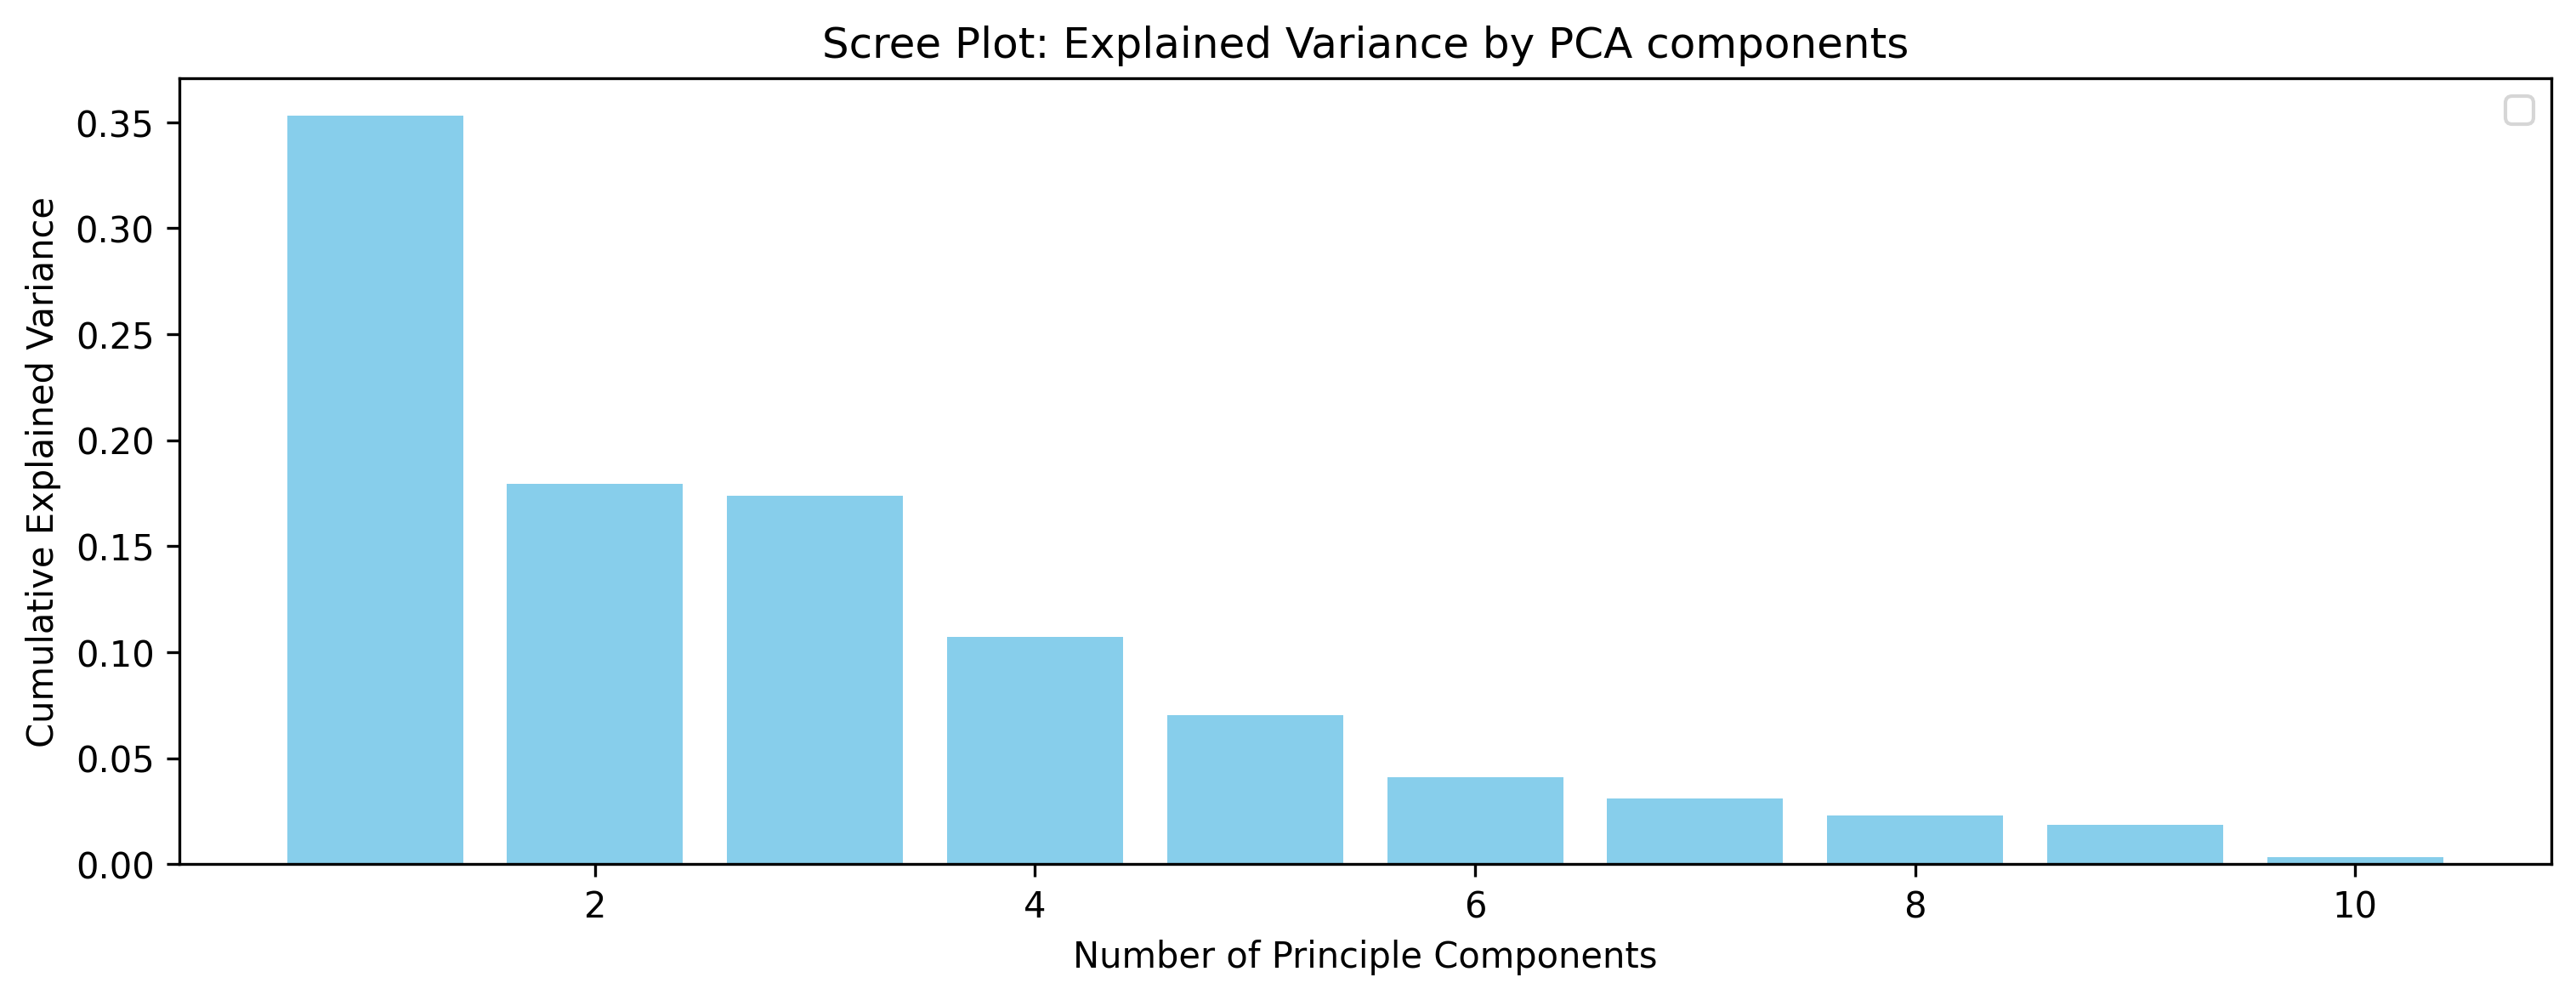

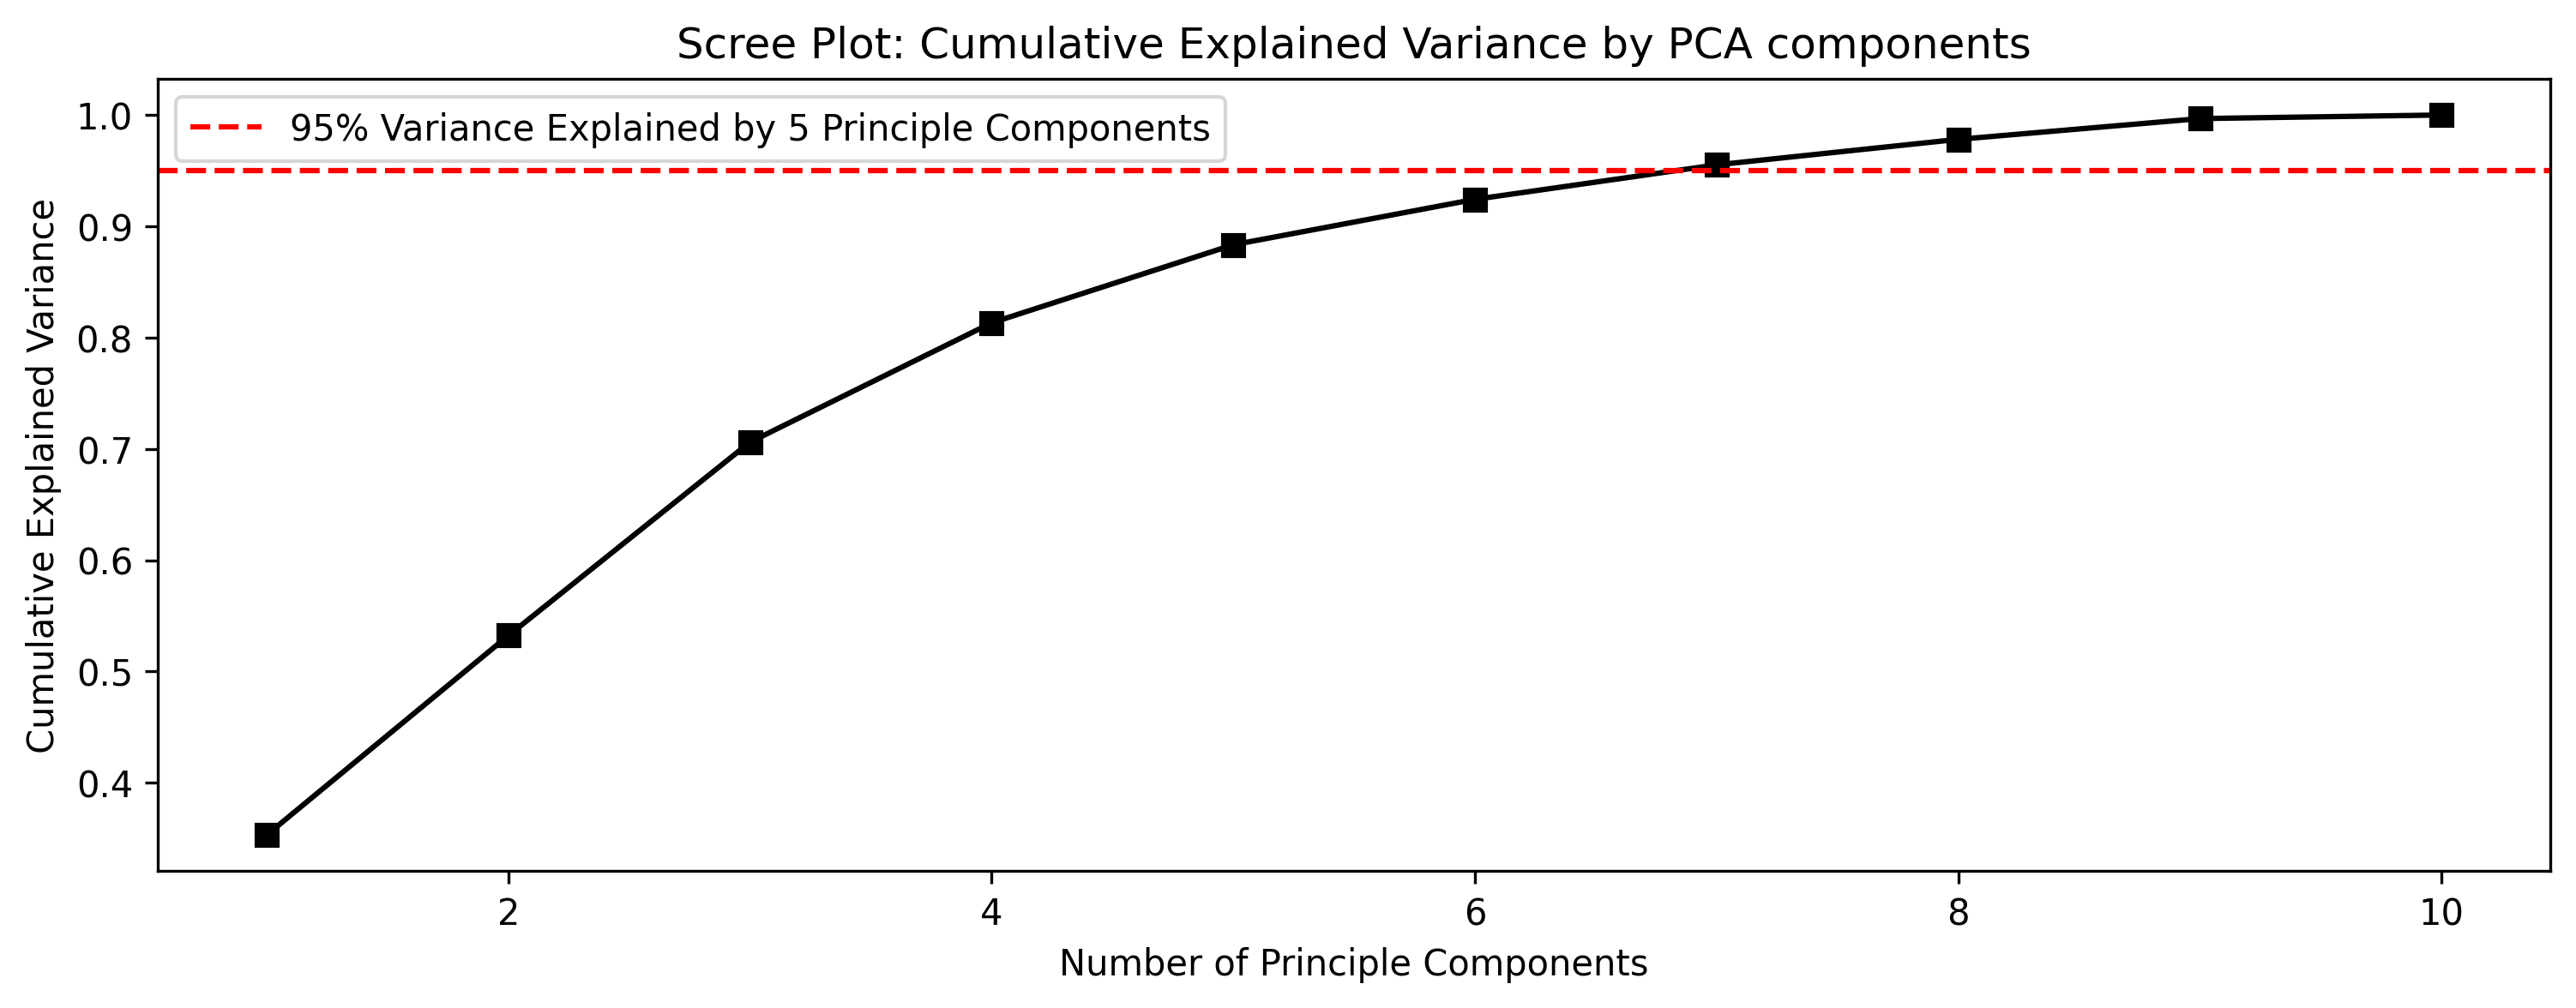

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(random_state = 42)
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
x_axis = range(1, len(cumulative_variance) +1)

plt.figure(figsize = (12,4), dpi = 300)
plt.bar(x_axis, explained_variance, color = "skyblue")
plt.title("Scree Plot: Explained Variance by PCA components")
plt.xlabel("Number of Principle Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.show()

plt.figure(figsize = (12,4), dpi = 300)
plt.plot(x_axis, cumulative_variance, marker = 's', color = 'black')
plt.axhline(y = 0.95, linestyle = '--', color = 'red', label = "95% Variance Explained by 5 Principle Components")
plt.title("Scree Plot: Cumulative Explained Variance by PCA components")
plt.xlabel("Number of Principle Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.show()

#### 2.2 Selecting the Ideal Number of KMean clusters

Silhouette scores were computed, and presented on a lineplot to validate the number of clusters/groups selected.

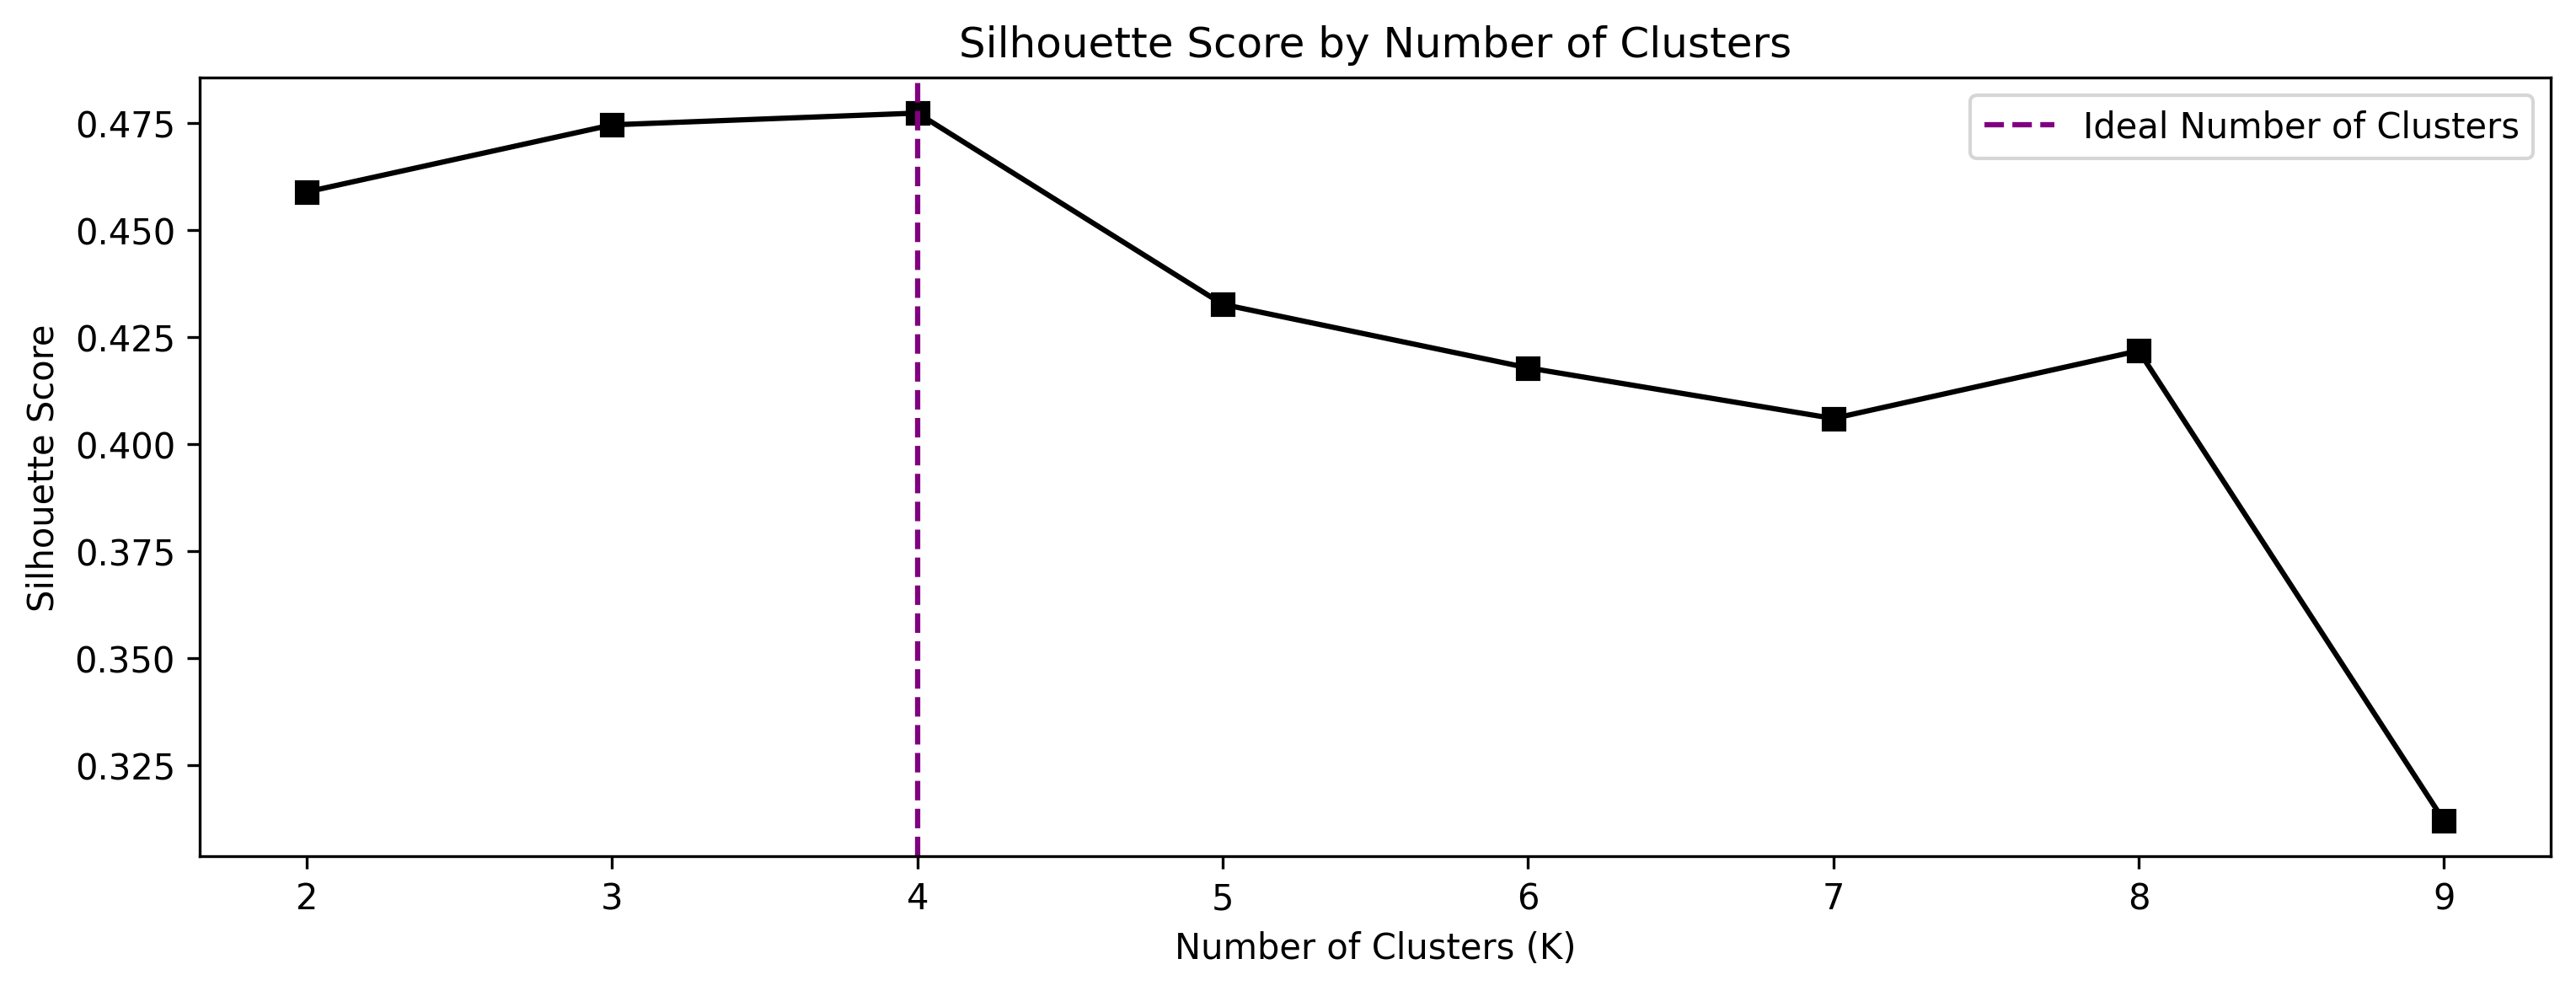

In [7]:
from sklearn.metrics import silhouette_score
pca_components = 7

pca = PCA(n_components = pca_components, random_state = 42)

X_pca = pca.fit_transform(X_scaled)

k_range = range(2,10)

s_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    k_labels = kmeans.fit_predict(X_pca)
    sil_score = silhouette_score(X_pca, k_labels)
    s_scores.append(sil_score)

plt.figure(figsize = (12,4), dpi = 300)
plt.plot(k_range, s_scores, marker = 's', color = "black")
plt.axvline(x = 4, color = 'purple', linestyle = '--', label = "Ideal Number of Clusters")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.show()

Ultimately, 4 clusters were selected as being ideal, being the highest silhouette score before the first drop, as can be noted from the plot above.

#### 2.3 Training the KMeans Customer Segmentation Model
The 7 principle components were fitted to the KMeans model with 4 clusters selected. After which, the model was stored as a joblib file, uploaded to AWS S3, and frozen to avoid version overwriting by rerunning the notebook.

To ensure the joblib file can effectively be used to assign customer segmentation, it was downloaded from S3, and the principal component features were passed to the loaded model to assign labels to each customer.


Successfully downloaded model from s3://sales-data-analytics-portfolio-2026/predictive_models/kmeans_segmentation_60.joblib


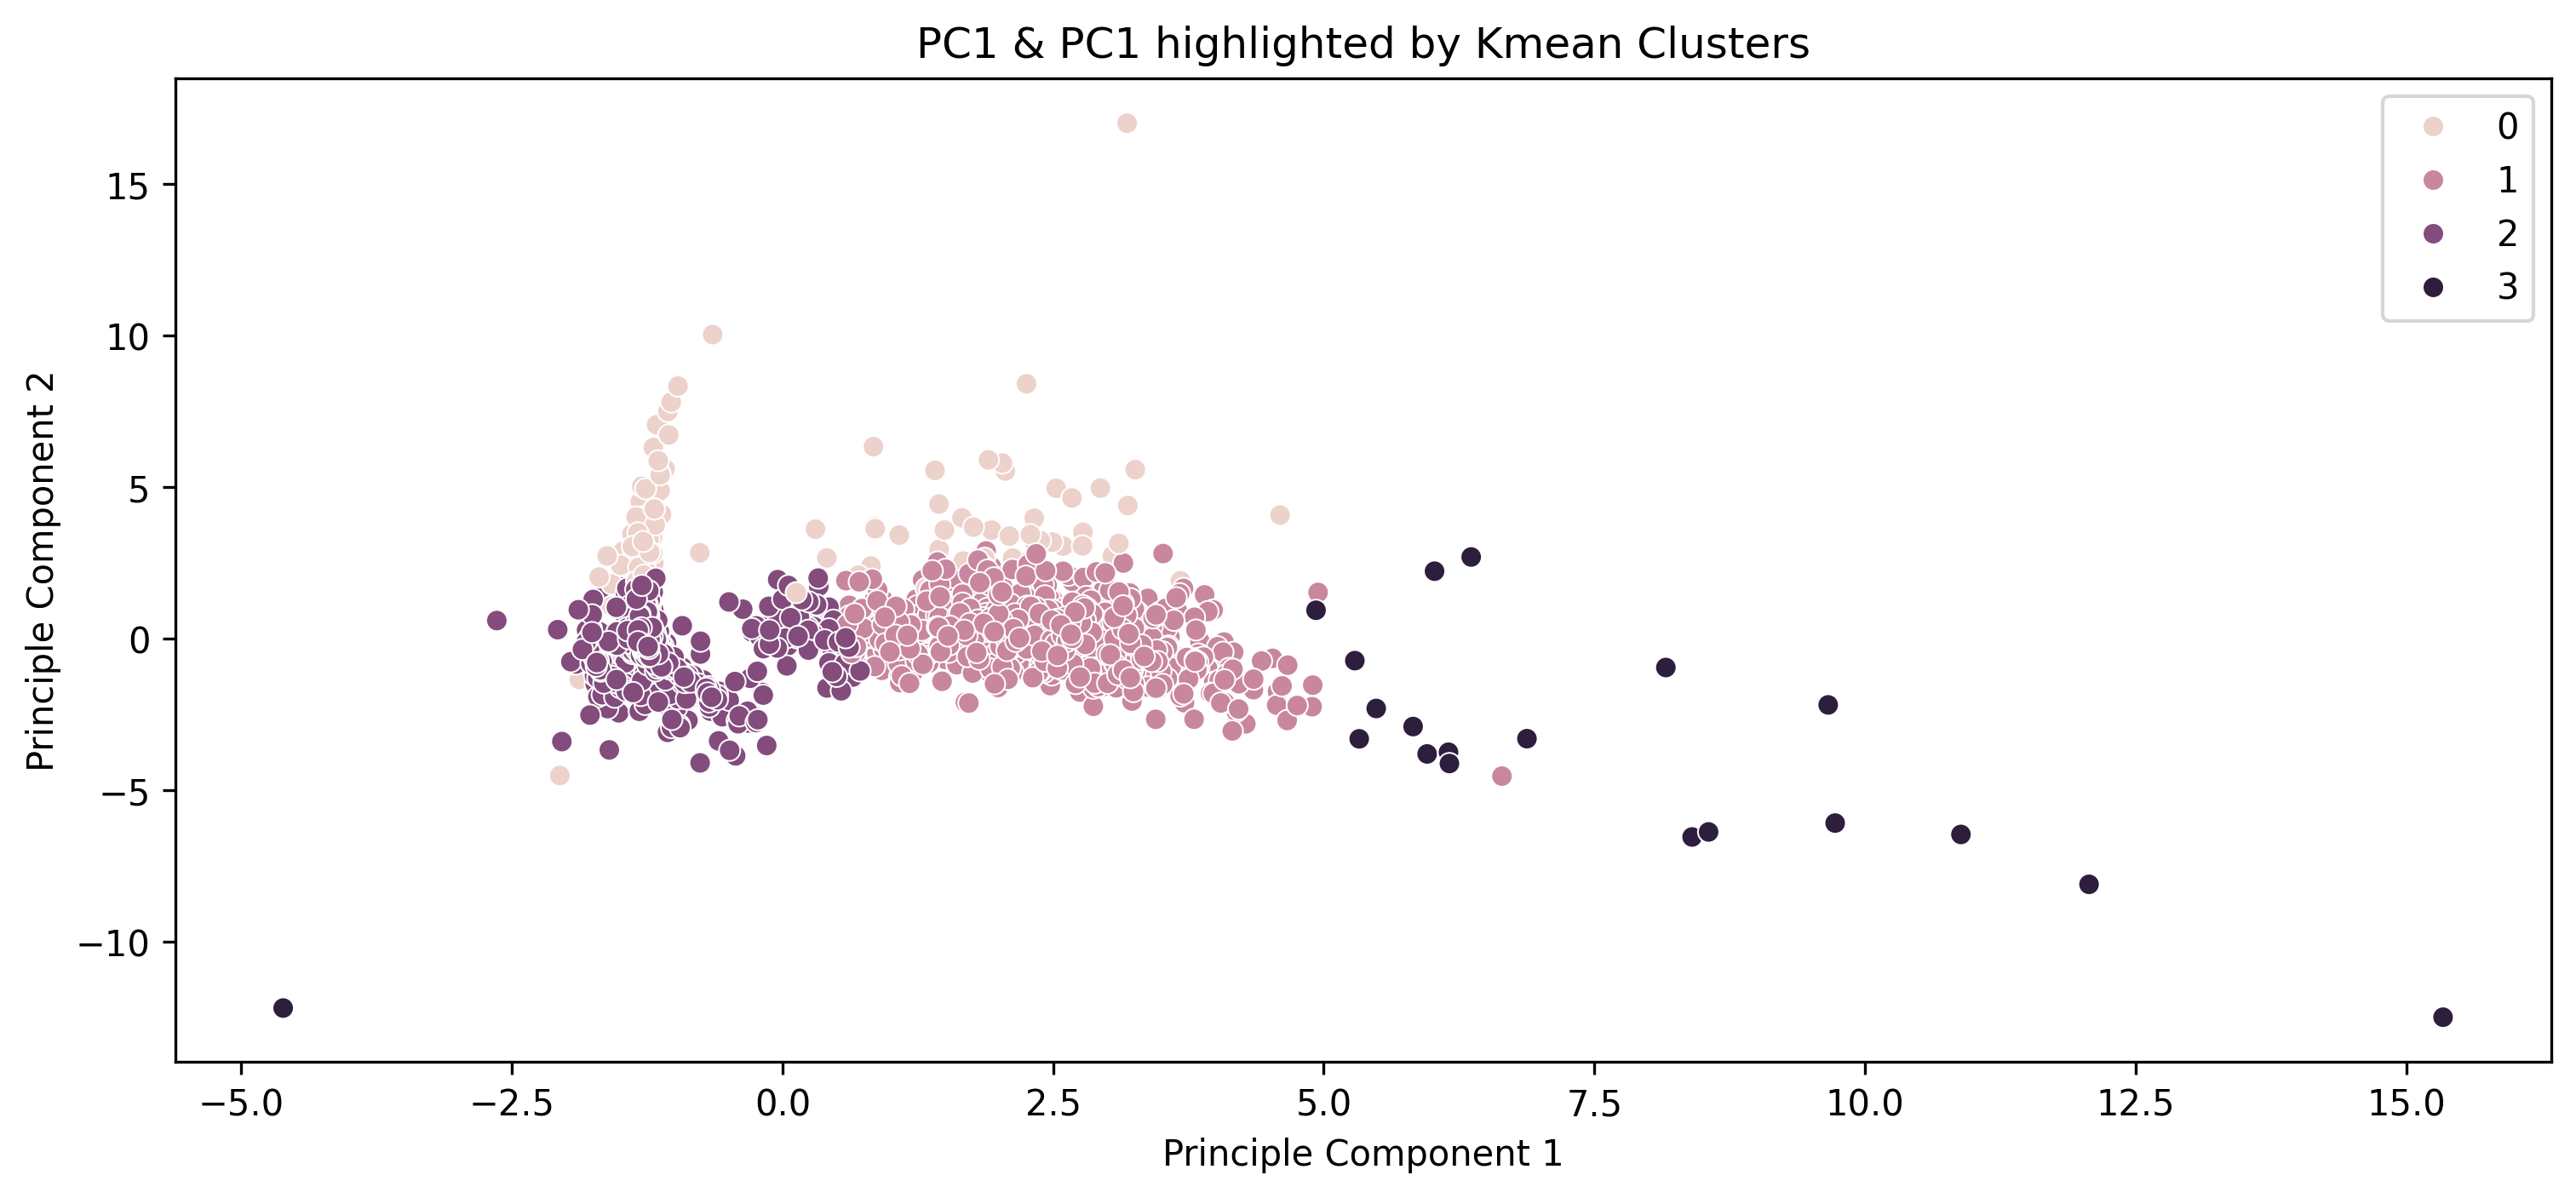

In [8]:
import joblib
import s3fs
from sklearn.pipeline import Pipeline

ideal_clusters = 4

#After fitting model without outliers, and storing in drive, all data including outliers were fitted

pipeline_steps = [
   ('scaler', StandardScaler()),
   #('pca', PCA(n_components = pca_components, random_state = 42)),
   ('kmeans', KMeans(n_clusters = ideal_clusters, random_state = 42, n_init = 10))
]

pipeline = Pipeline(pipeline_steps)
pipeline.fit(X)

fs = s3fs.S3FileSystem()

file_path = "s3://sales-data-analytics-portfolio-2026/predictive_models/kmeans_segmentation_60.joblib"

#with fs.open(file_path, "wb") as f:
    #joblib.dump(pipeline, f)
#print(f'Successfully Saved KMeans Model to {file_path}')

with fs.open(file_path, "rb") as f:
    loaded_model = joblib.load(f)

print(f"\nSuccessfully downloaded model from {file_path}")
k_labels = loaded_model.predict(X)

pc1 = X_pca[:,0]
pc2 = X_pca[:,1]

plt.figure(figsize = (12,5), dpi = 300)
sns.scatterplot(x = pc1, y = pc2, hue = k_labels)
plt.title("PC1 & PC1 highlighted by Kmean Clusters")
#plt.axhline(y = 2.4, color = "grey", linestyle = '--')
#plt.axvline(x = 0.3, color = "grey", linestyle = '--')
#plt.axvline(x = 5, color = "grey", linestyle = '--')
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.show()

To check whether the model genuinely found distinct patterns, the labels were highlighted on a scatter plot of PCA1 and PCA2, as displayed above, to visibly see the separations made by the model. Clearly the model identified 4 distinct groups, with clear separations.

### 3.0 PROFILING AND DEFINING THE KMEANS CLUSTER LABELS

KMeans labels were assigned; creating the task to profile and translate the abstract labels into business meaning. This was done with the aid of visualisations; a heatmap showing actual median values across labels, and boxplots displaying the spread of data points across labels.

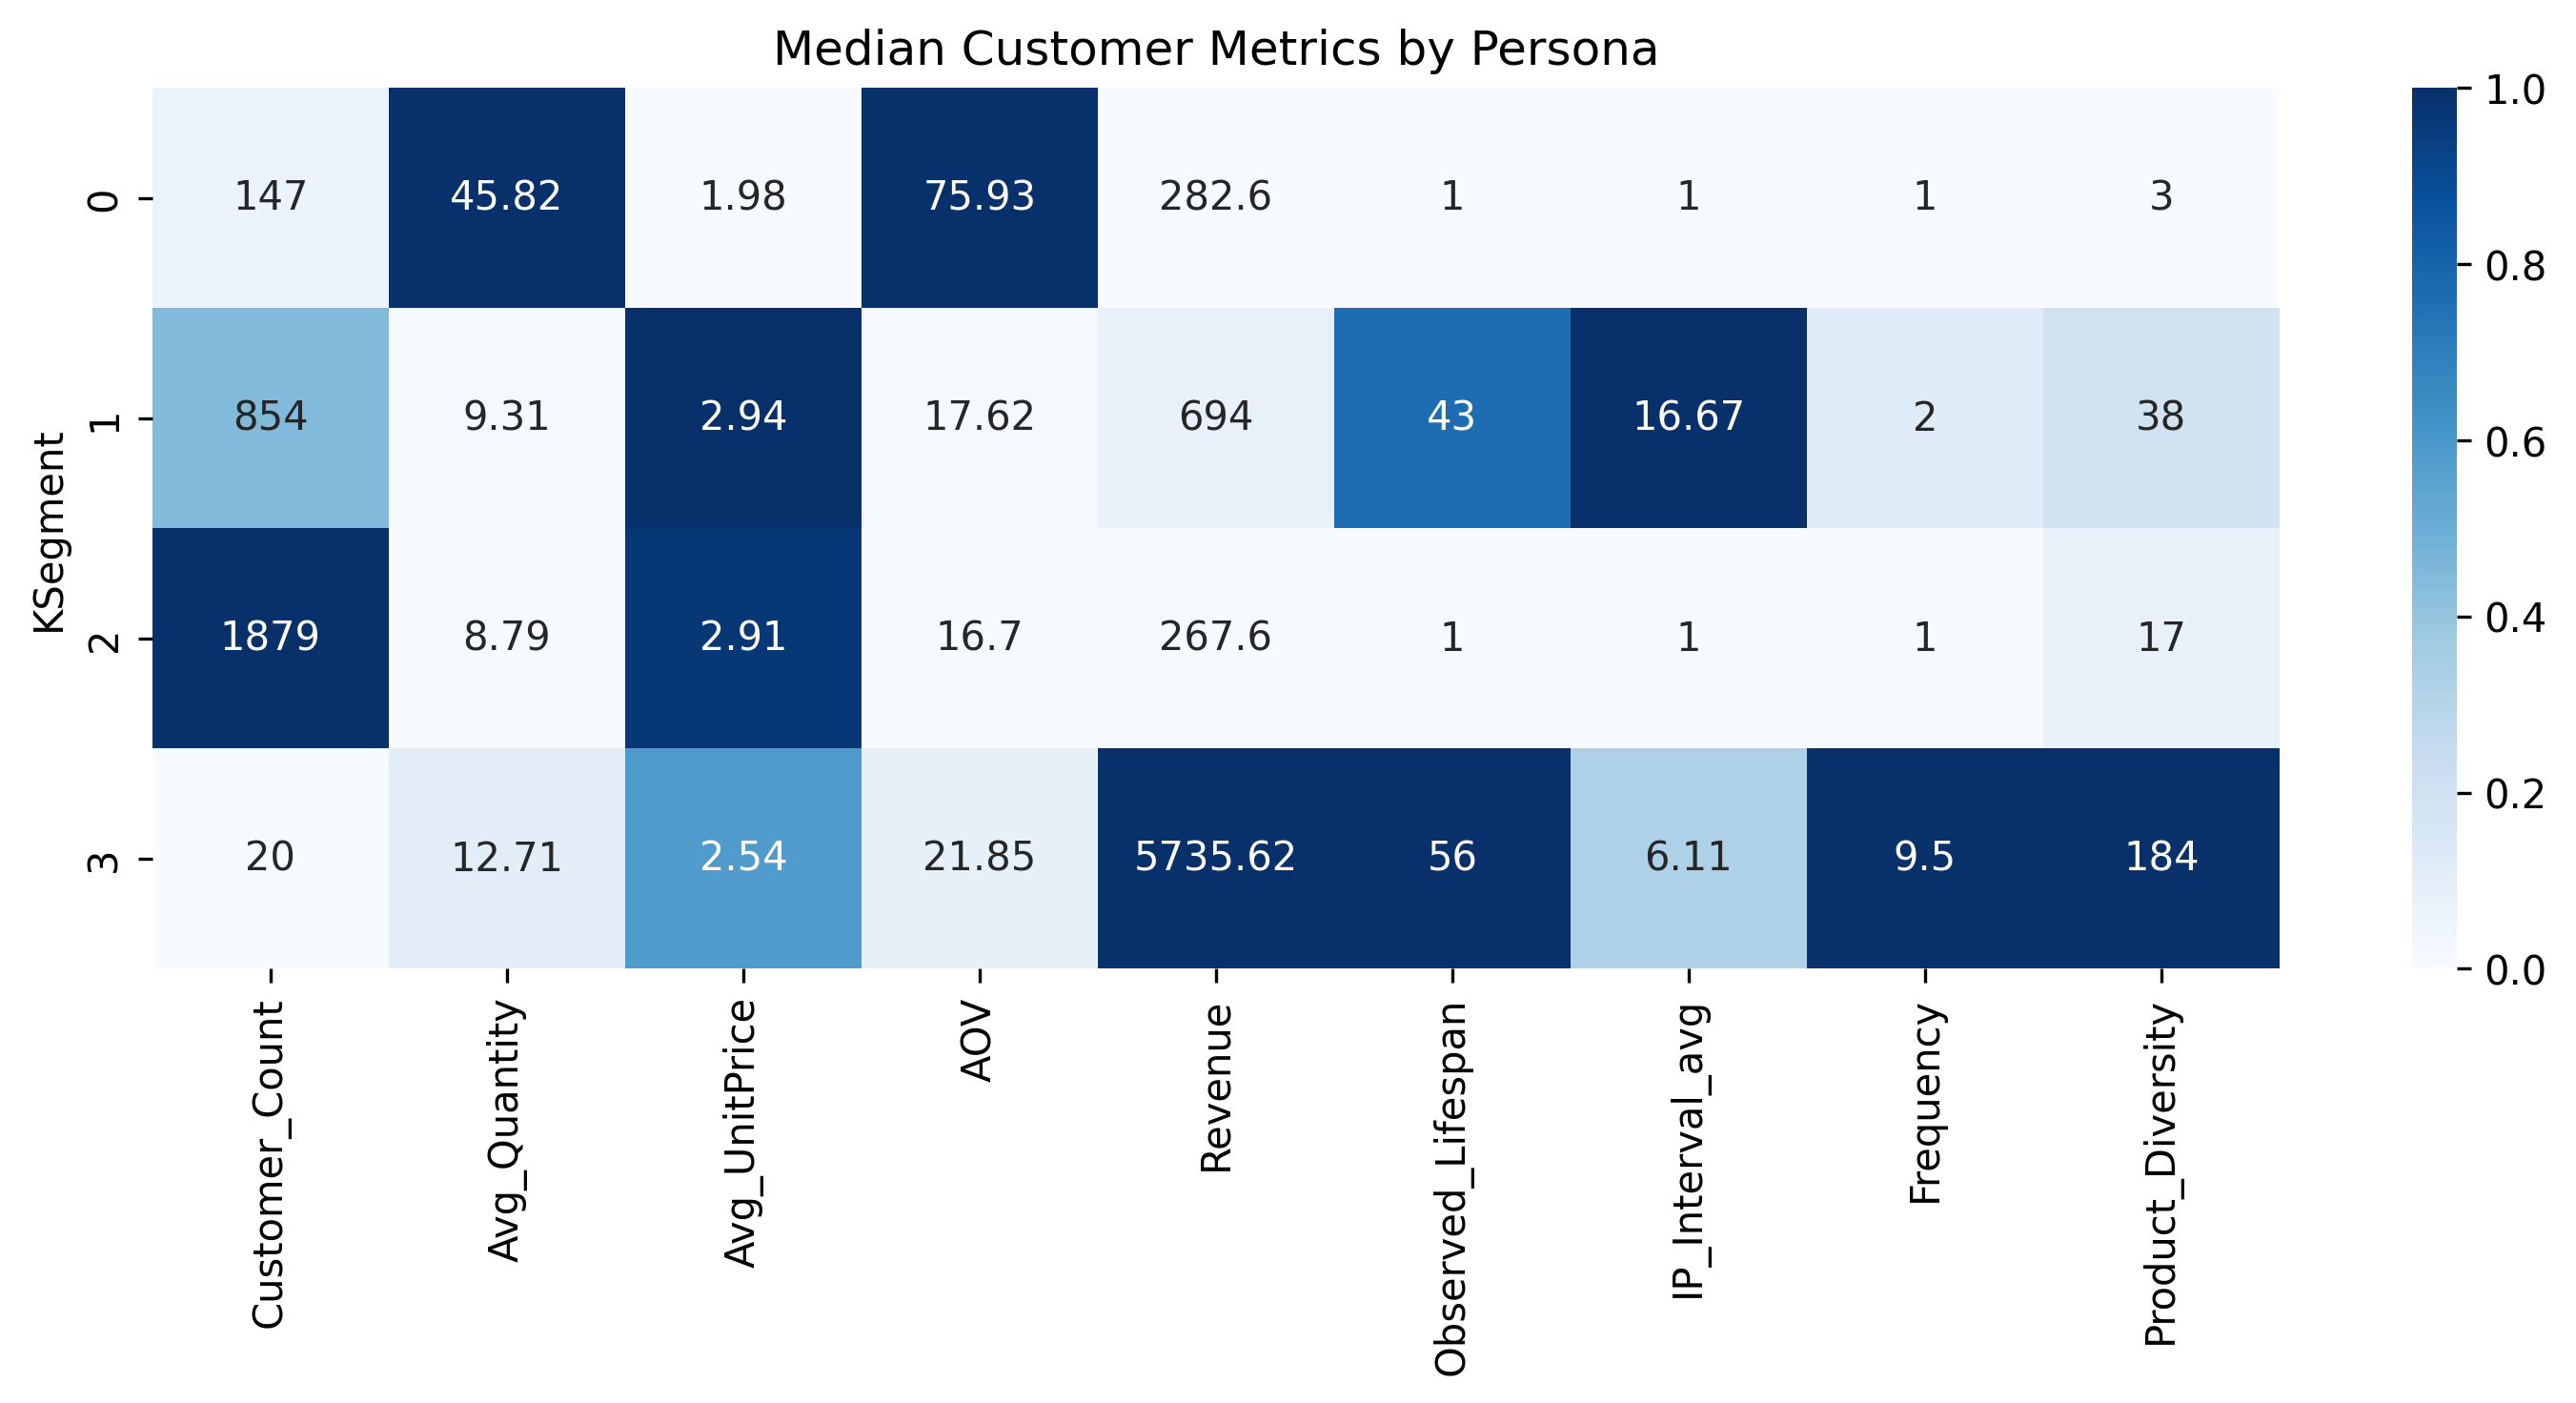

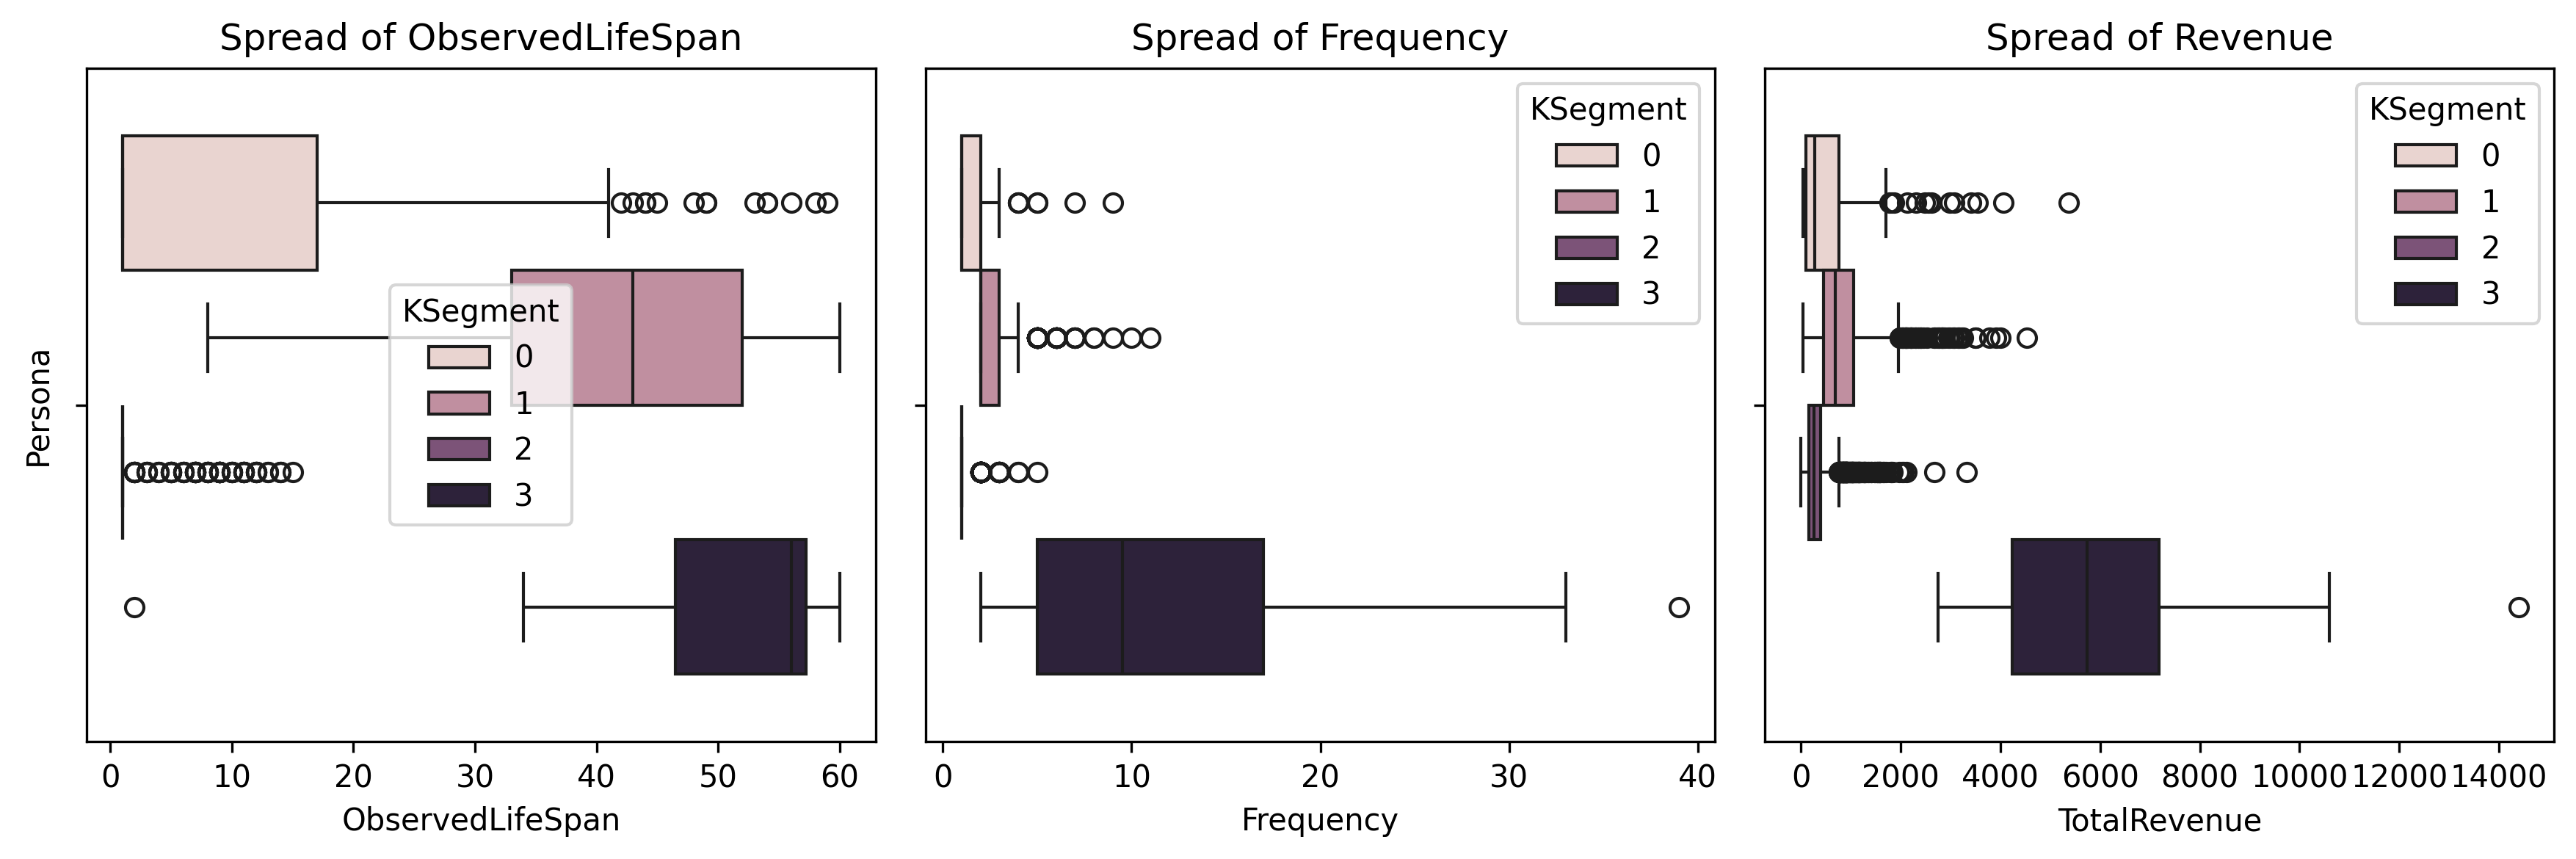

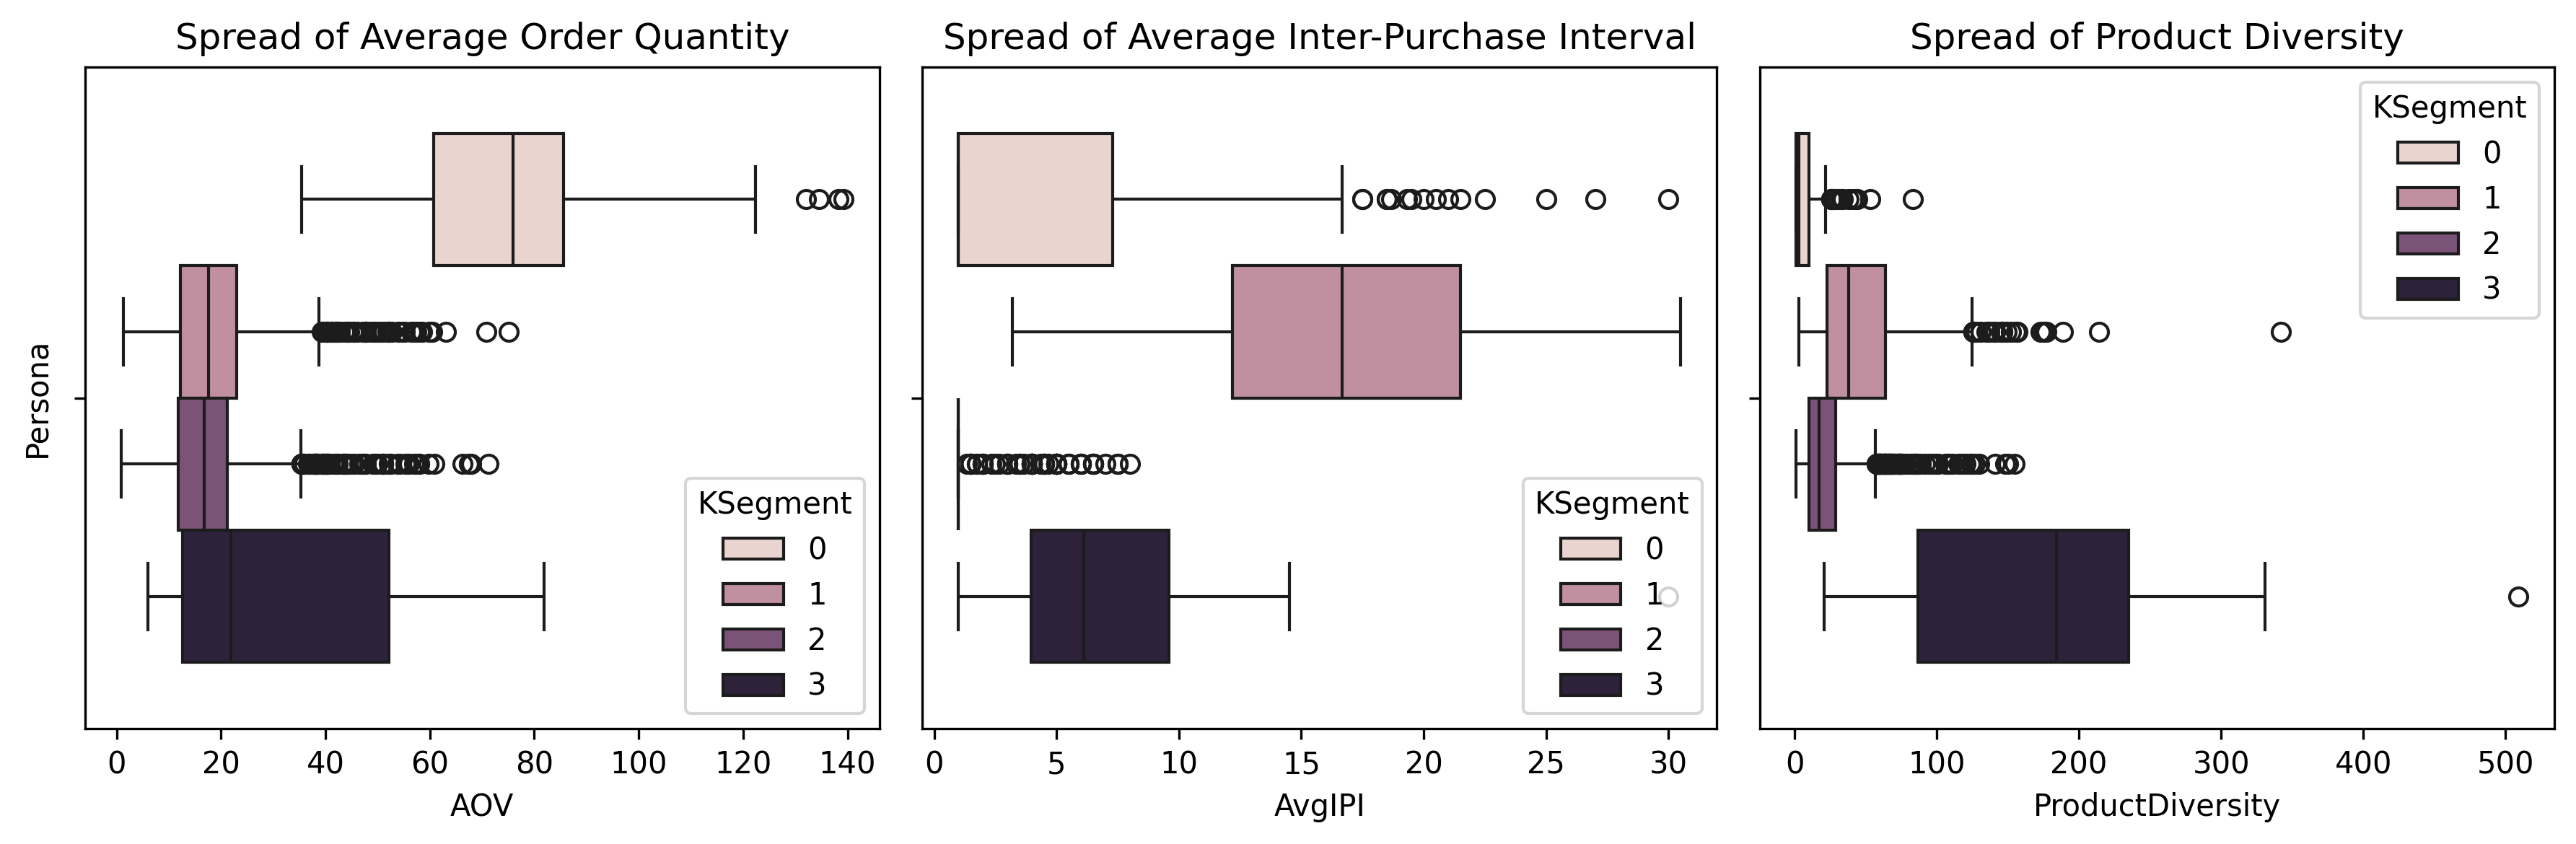

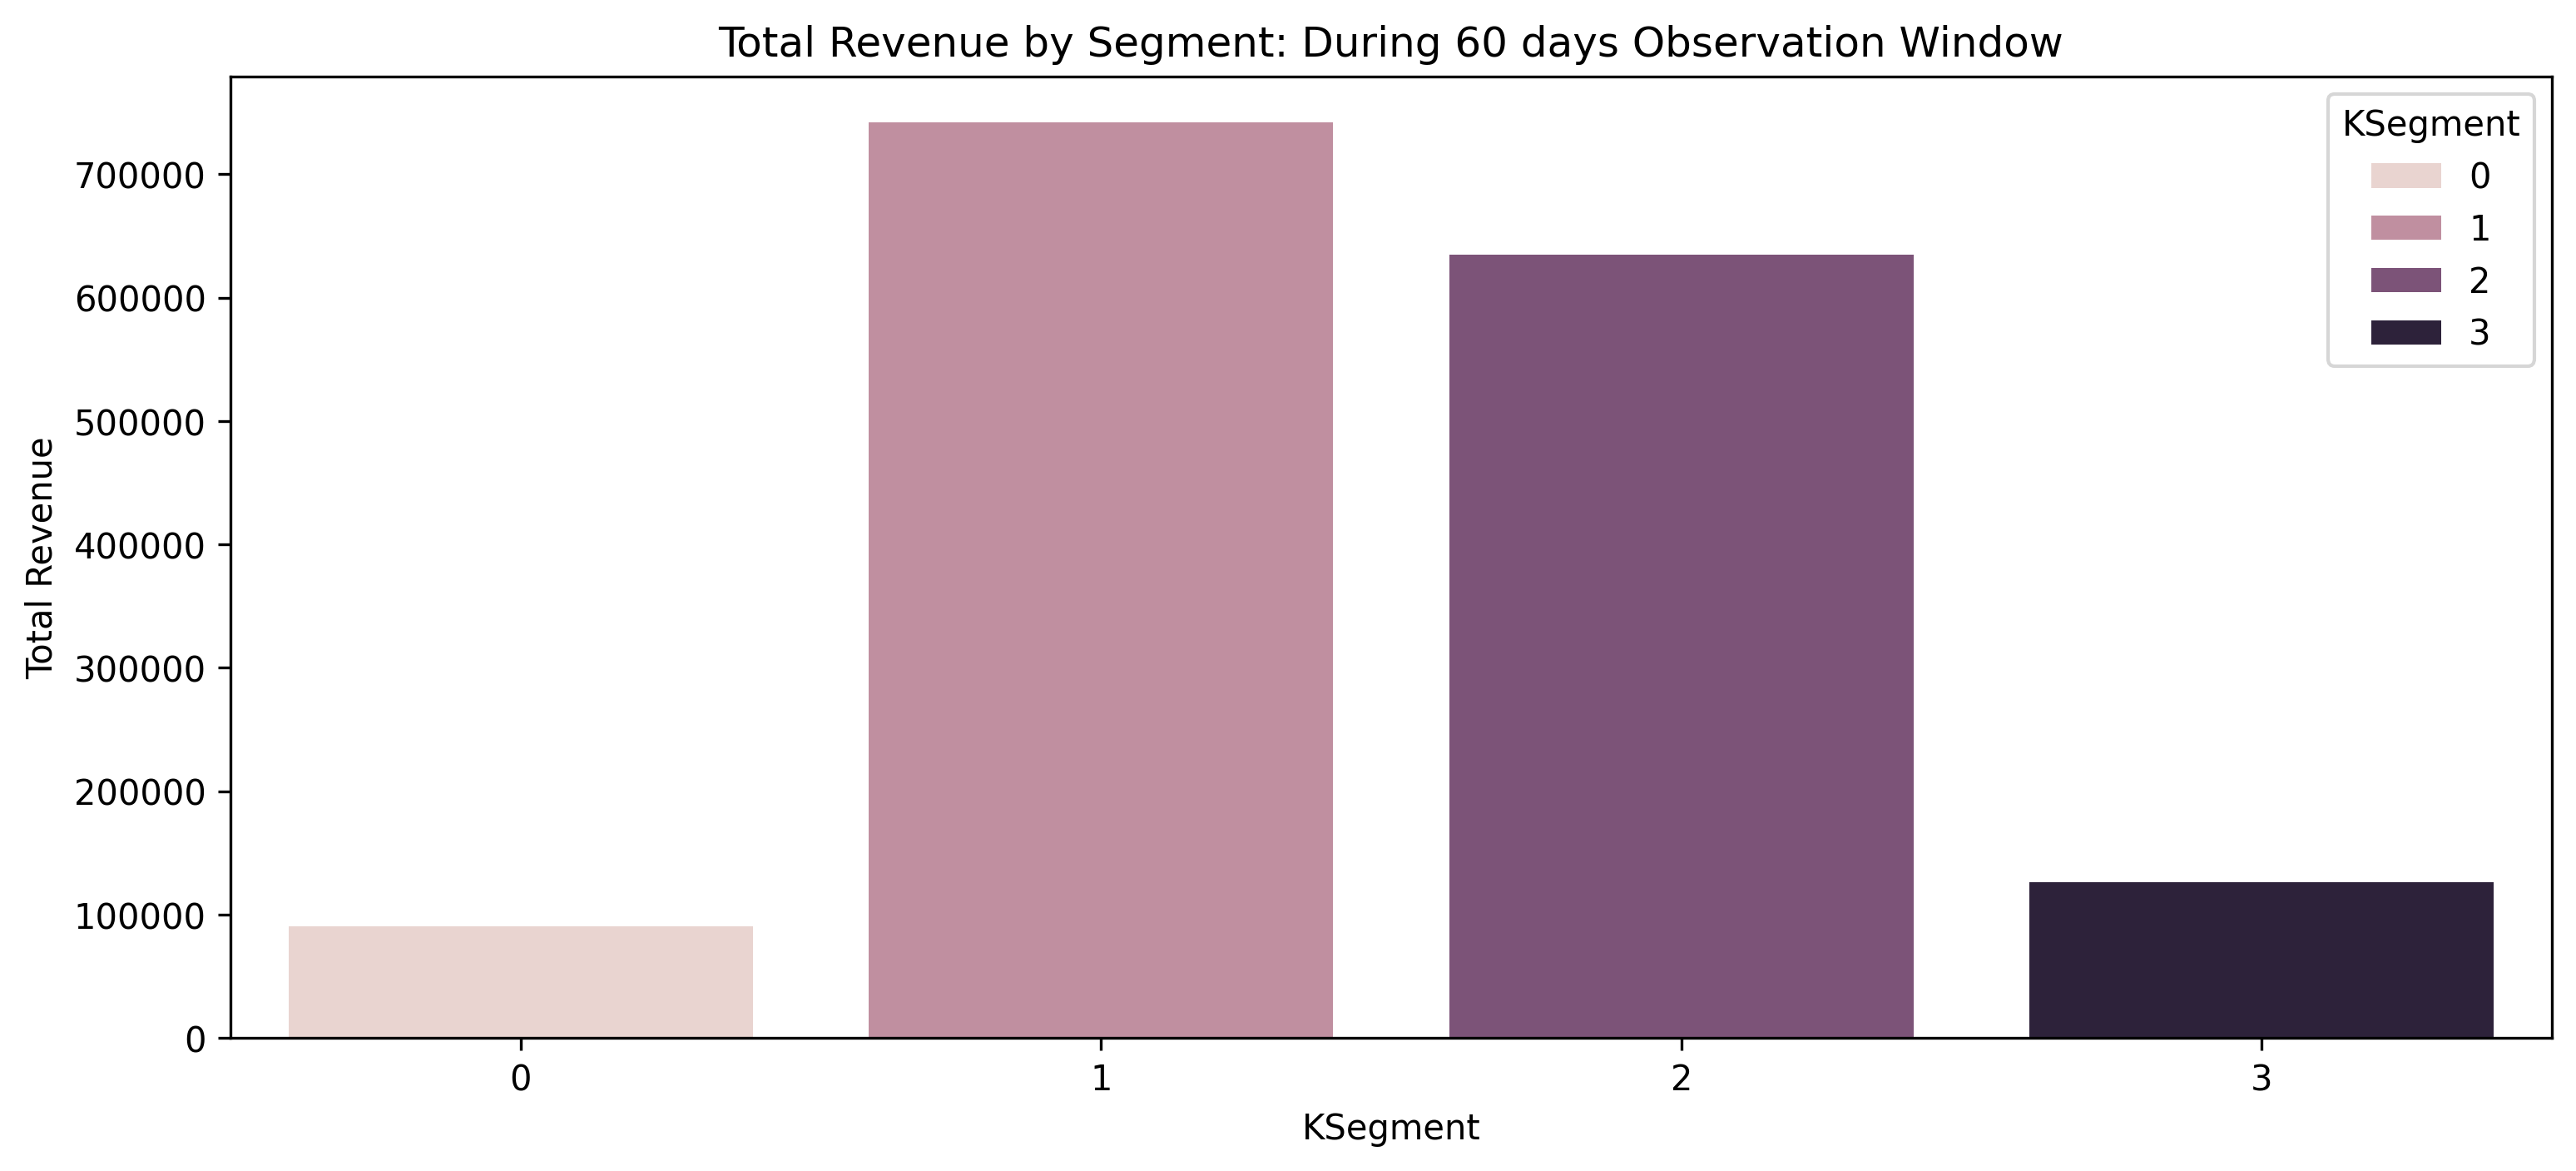

In [9]:
features["KSegment"] = k_labels

medians = features.groupby("KSegment").agg(
  Customer_Count = ("CustomerID", "count"),
  Avg_Quantity = ("AvgQuantity", "median"),
  Avg_UnitPrice = ("AvgUnitPrice", "median"),
  AOV = ("AOV", "median"),
  Revenue = ("TotalRevenue", "median"),
  Observed_Lifespan = ("ObservedLifeSpan", "median"),
  IP_Interval_avg = ("AvgIPI", "median"),
  Frequency = ("Frequency", "median"),
  Product_Diversity = ("ProductDiversity", "median")).round(2)

#medians = df.groupby("KSegment")[['Frequency', 'Recency', 'TotalRevenue', 'Tenure', 'ProductDiversity']].median()
medians_norm = (medians - medians.min())/(medians.max() - medians.min())

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(data = medians_norm, annot = medians, fmt = 'g', cmap = 'Blues')
plt.title('Median Customer Metrics by Persona')
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1,3, dpi = 300, figsize = (12,4))
sns.boxplot(data = features, x = "ObservedLifeSpan", hue = "KSegment", ax = ax1)
ax1.set_title("Spread of ObservedLifeSpan")
ax1.set_ylabel("Persona")

sns.boxplot(data = features, x = "Frequency", hue = "KSegment", ax = ax2)
ax2.set_title("Spread of Frequency")
ax1.set_ylabel("Persona")

sns.boxplot(data = features, x = "TotalRevenue", hue = "KSegment", ax = ax3)
ax3.set_title("Spread of Revenue")
ax1.set_ylabel("Persona")

plt.tight_layout()
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1,3, dpi = 300, figsize = (12,4))
sns.boxplot(data = features, x = "AOV", hue = "KSegment", ax = ax1)
ax1.set_title("Spread of Average Order Quantity")
ax1.set_ylabel("Persona")

sns.boxplot(data = features, x = "AvgIPI", hue = "KSegment", ax = ax2)
ax2.set_title("Spread of Average Inter-Purchase Interval")
ax1.set_ylabel("Persona")

sns.boxplot(data = features, x = "ProductDiversity", hue = "KSegment", ax = ax3)
ax3.set_title("Spread of Product Diversity")
ax1.set_ylabel("Persona")

plt.tight_layout()
plt.show()

filters = ["CustomerID", "TotalRevenue", "Frequency", "ObservedLifeSpan", "AvgIPI", "KSegment"]
filters_100 = ["CustomerID", "TotalRevenue", "Frequency", "ObservedLifeSpan", "AvgIPI"]

merged_df = features[filters].merge(after_cutoff[filters_100], how = 'left', on = "CustomerID", suffixes = ["_60", "_100"]).fillna(0)

plt.figure(figsize = (12,5), dpi = 300)
sns.barplot(data = merged_df, x = "KSegment", y = "TotalRevenue_60", errorbar = None, hue = "KSegment", estimator = "sum")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Segment: During 60 days Observation Window")
plt.show()

Describing and distinguishing cluster labels from the above plots.
- `Cluster 2` and `Cluster 0` typically have a median `Frequency` of 1 and an `ObservedLifeSpan` of 1, as presented on the heatmap, implying that these customers typically make only 1 purchase during their first 60 days, with a few outliers. The key differences, are that `Cluster 0` are specialised bulk buyers, with the highest median `AOV` and the cheapest median `UnitPrice`, while `Cluster 2` has a higher `ProductDiversity` due to its high customer count. Based on their similarities and differences `Cluster 2` was labelled as `One-Time Acquaintances`, and `Cluster 0` as `One-Time Bulk Buyers`.

- One the other hand, `Cluster 1` is the second largest segment, with the highest median `AvgUnitPrice`, and typically contribute the largest revenue share during the 60-day tenure. Unlike `Cluster 0` and `Cluster 2`, these are clients who come back to make a second purchase at least 8 days after their first, with an average InterPurchaseInterval interval of 16, suggesting that on average we expect these clients to make a repeat purchase after 16 days on average. That said, acknowledging their large revenue contribution, high average UnitPrice, and attribute of making more than one purchase during observation, `Cluster 1` were labelled as `Loyal Performers`.

- Lastly, `Cluster 3` holds the highest median revenue, spending more than `9x` of `Cluster 1`, and based of their InterPurchaseInterval; typically puchase every `4 days` on average, which is the best Interval among the segments. These clients are loyal, dependable, and highly reliable, with a median `ProductDiversity` of 168. This segment, although the smallest, outperforms the other segments, they are the `Dream-Team` of the business, and are classified as the `High-Value Elite` segment.

### 4.0 SEGMENTATION ANALYSIS, 100 DAYS AFTER CROSSING THE 60 DAY TENURE.

This section, aims at exploring performance by segment, to get a picture of customer behaviour, within the 100 days after first 60 days tenure is met, and gain further insights into each segment, with a primary focus on `Churn rate`, `Customer Spend`, `InterPurchaseInterval`, and `ObservedLifeSpan`.

#### 4.1 Analysing Customer Churn

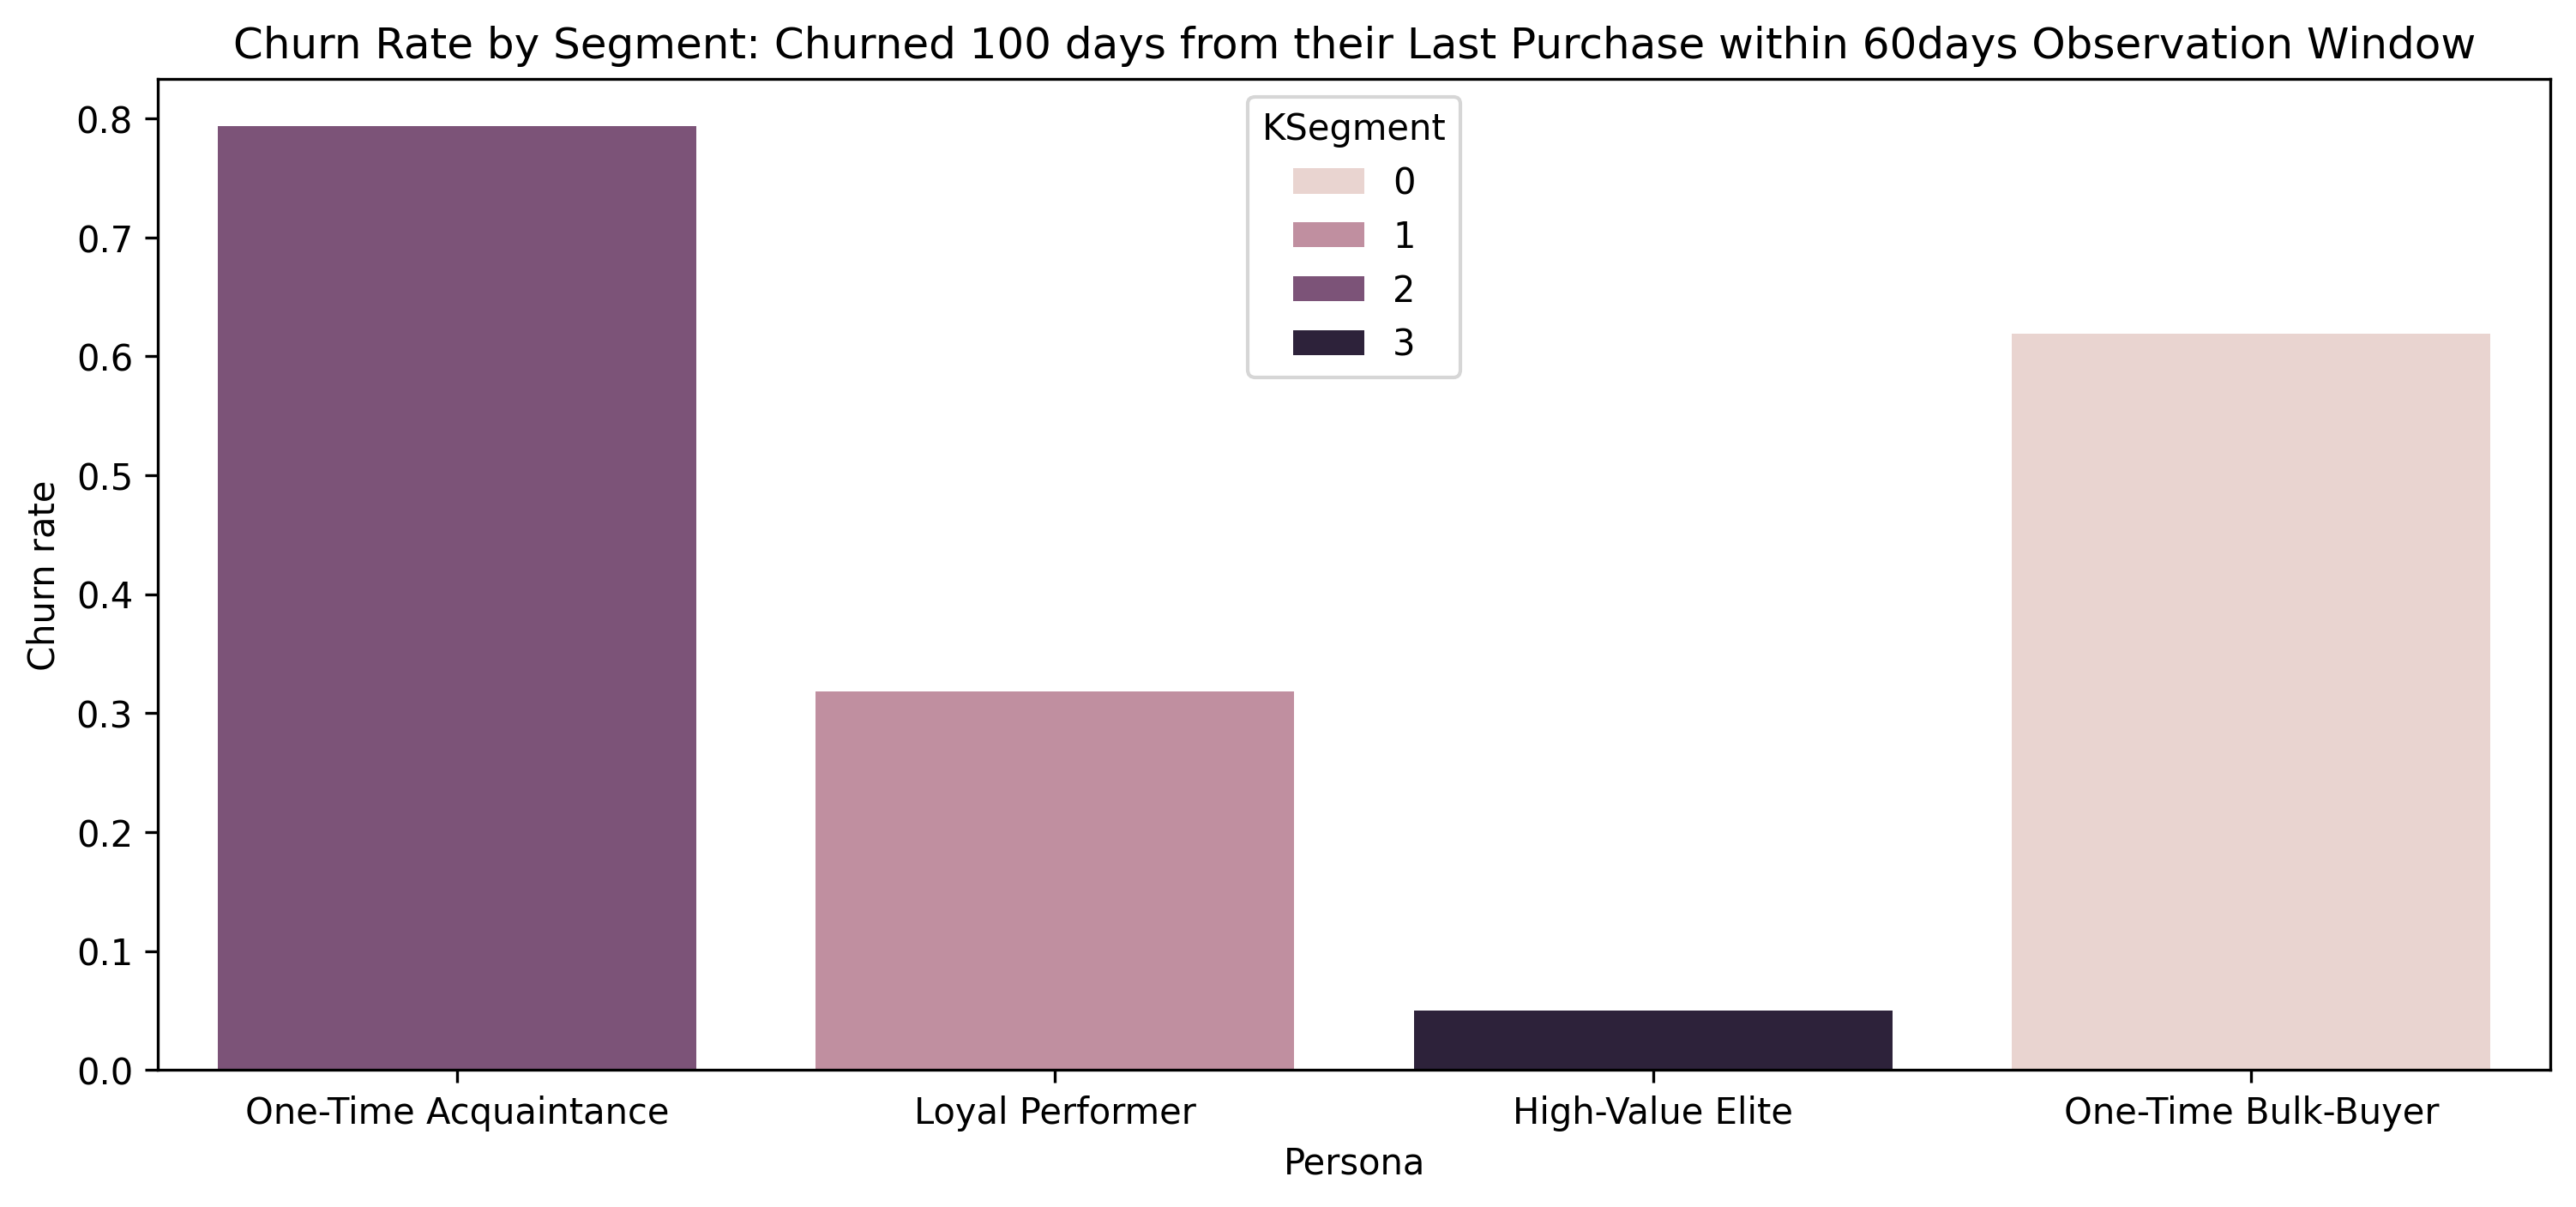

Persona,High-Value Elite,Loyal Performer,One-Time Acquaintance,One-Time Bulk-Buyer
Retained,19,582,388,56
Churned,1,272,1491,91
Total Customers,20,854,1879,147
Retention Rate,95.0%,68.15%,20.65%,38.1%
Churn Rate,5.0%,31.85%,79.35%,61.9%


In [10]:
segment_map = {
2: "One-Time Acquaintance",
0: "One-Time Bulk-Buyer",
1: "Loyal Performer",
3: "High-Value Elite"
}

order = ["One-Time Acquaintance", "Loyal Performer", "High-Value Elite", "One-Time Bulk-Buyer"]

features["Persona"] = features["KSegment"].map(segment_map)


filters = ["CustomerID", "Frequency", "KSegment","Persona"]
merged_df = features[filters].merge(after_cutoff, how = 'left', on = "CustomerID", suffixes = ["_60", "_100"]).fillna(0)

merged_df["Churned"] = np.where(merged_df["Frequency_100"] == 0, 1, 0)

plt.figure(figsize = (12,5), dpi = 300)
sns.barplot(data = merged_df, x = "Persona", y = "Churned", errorbar = None, hue = "KSegment", order = order)
plt.ylabel("Churn rate")
plt.title("Churn Rate by Segment: Churned 100 days from their Last Purchase within 60days Observation Window")
plt.show()


summary = pd.DataFrame(merged_df.groupby(["Persona","Churned"]).size()).unstack()
summary.columns = summary.columns.get_level_values(1)
summary.columns = ["Retained", "Churned"]
summary["Total Customers"] = summary["Churned"] + summary["Retained"]
summary["Retention Rate"] = (summary["Retained"]/(summary["Retained"] + summary["Churned"]) *100).round(2).astype("str") + "%"
summary["Churn Rate"] = (summary["Churned"]/(summary["Retained"] + summary["Churned"]) *100).round(2).astype("str") + "%"
summary.transpose()

`Customer Churn Analysis` in the first 100 days after the 60-day tenure mark, revealed that the `One-Time Acquaintances` registered the higest churn rate (79.35%), followed by `One-Time Bulk-Buyers` (61.90%).

On the other hand, the `High-Value Elite` segment, outforms the rest, having the highest retention rate (95.00%), with the `Loyal Performers` ranked second at a rate of 68.15%. These numbers, reflect that the segmentation, captures patterns that extent beyond the trained period.

#### 4.2 Reviewing Revenue Contribution by Segment During The first 100 days after the 60-day Tenure mark.

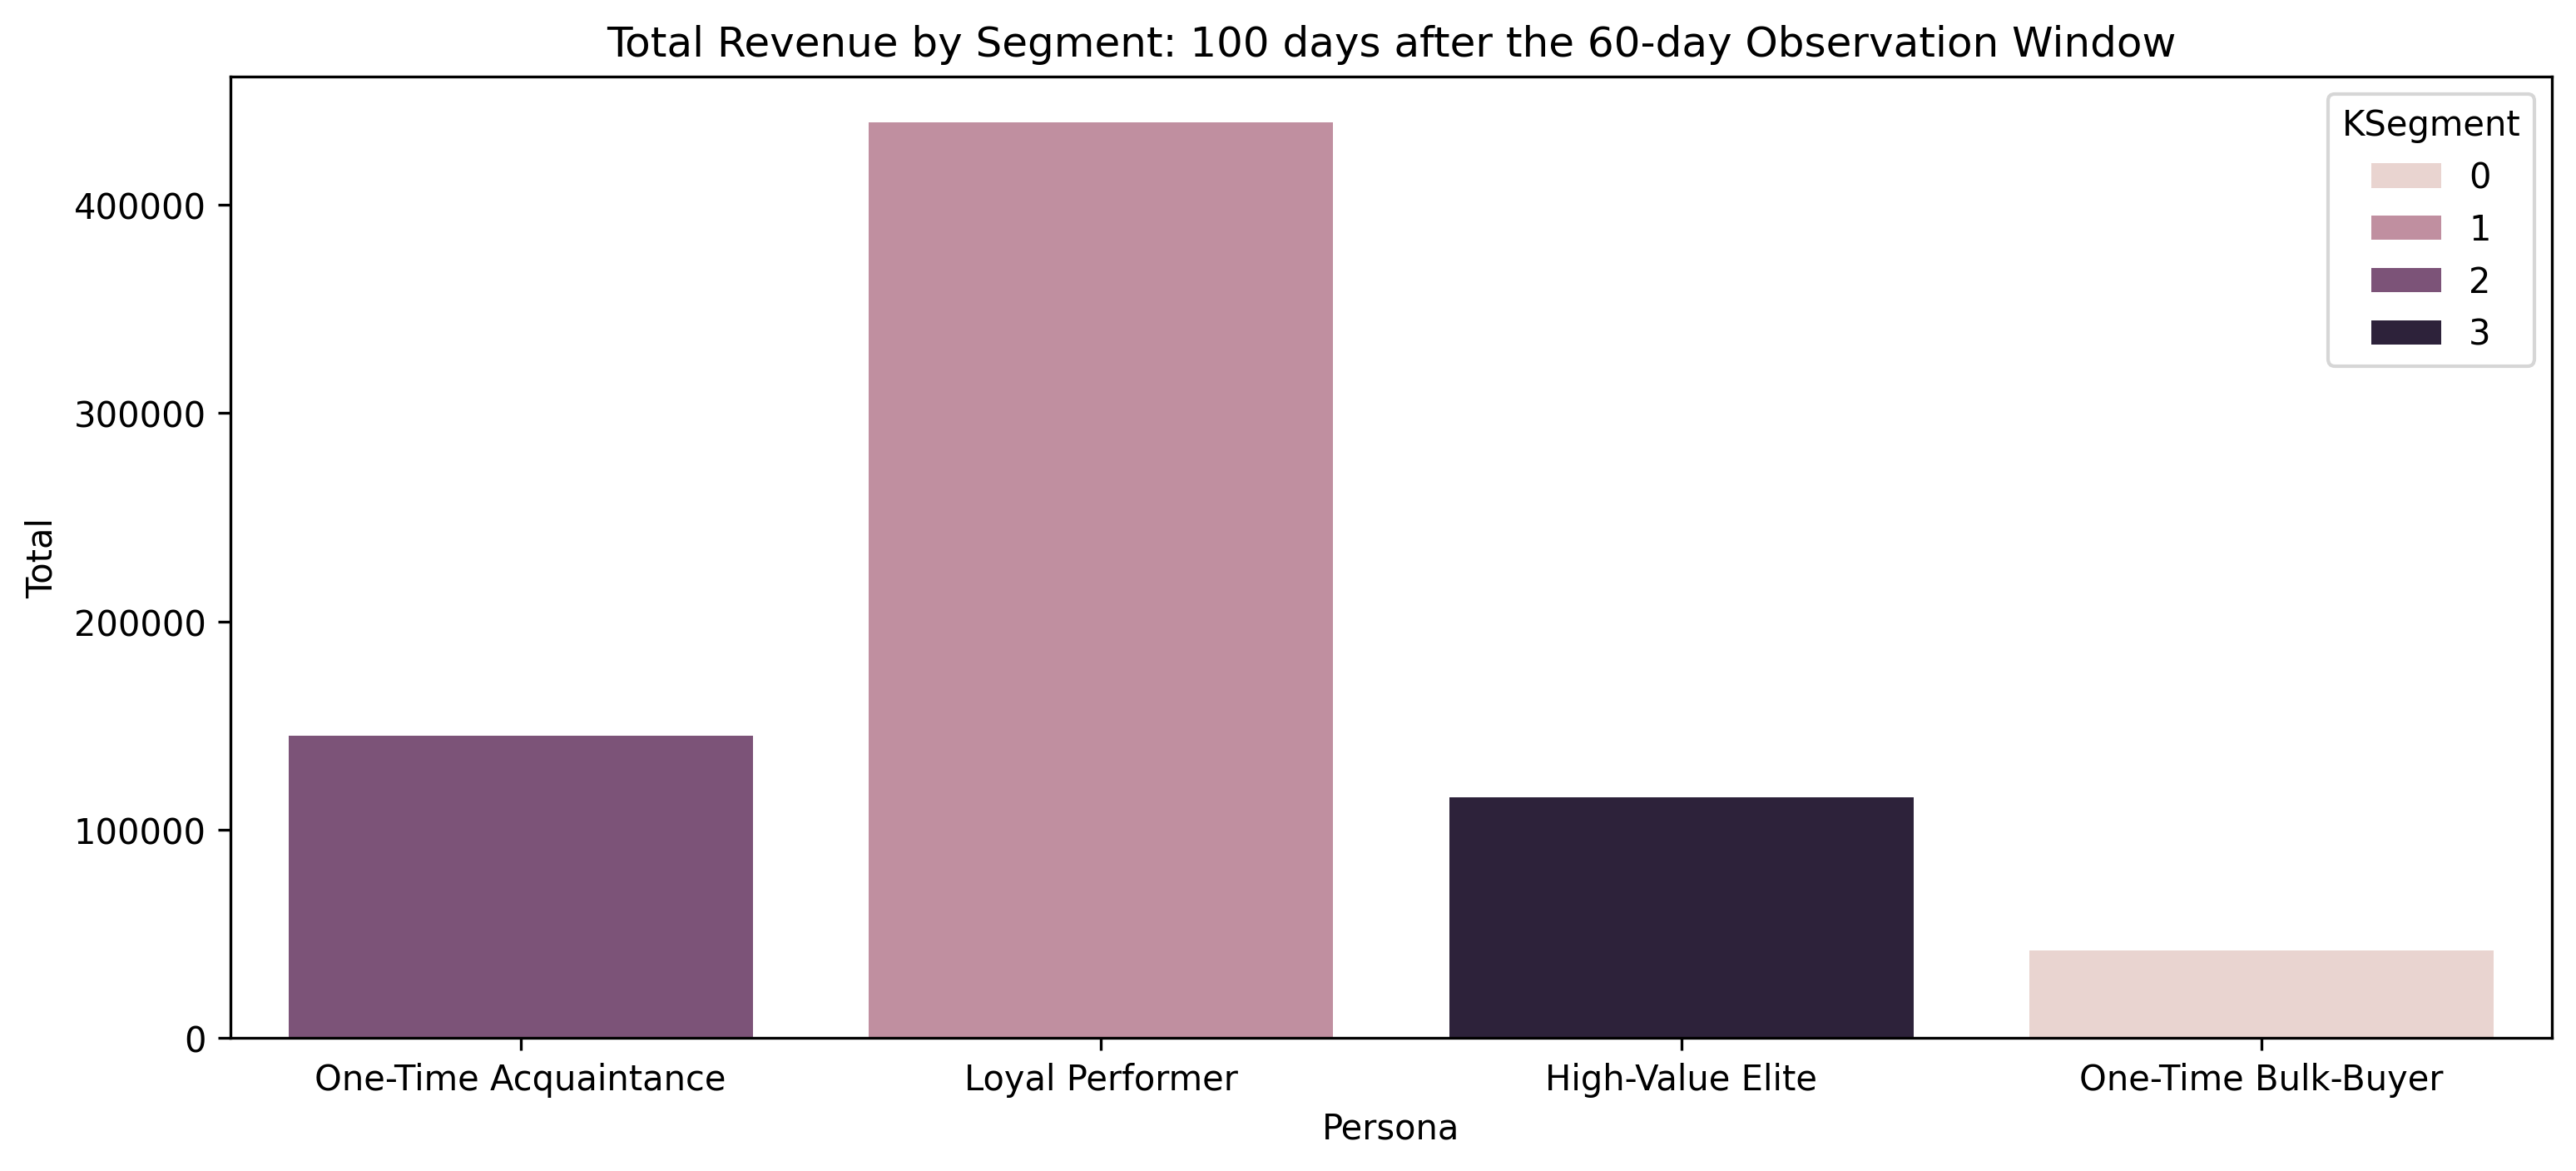

In [11]:
plt.figure(figsize = (12,5), dpi = 300)
sns.barplot(data = merged_df, x = "Persona", y = "TotalRevenue", errorbar = None, hue = "KSegment", estimator = "sum", order = order)
plt.ylabel("Total")
plt.title("Total Revenue by Segment: 100 days after the 60-day Observation Window")
plt.show()


summary = pd.DataFrame(merged_df.groupby(["KSegment","Churned"]).size()).unstack()
summary.columns = summary.columns.get_level_values(1)

The `Loyal Performers`, during the period of focus, generated the highest revenue during the 100-day target period , more than the other 3 segments combined. The proportion of revenue for the `One-Time Acquaintances` drops significantly in the 100-day window compared to the 60-day.

#### 4.3 Reviewing The ObservedLifeSpan vs  TotalRevenue Relationship, and The Average InterPurchaseInterval and TotalRevenue Relationship

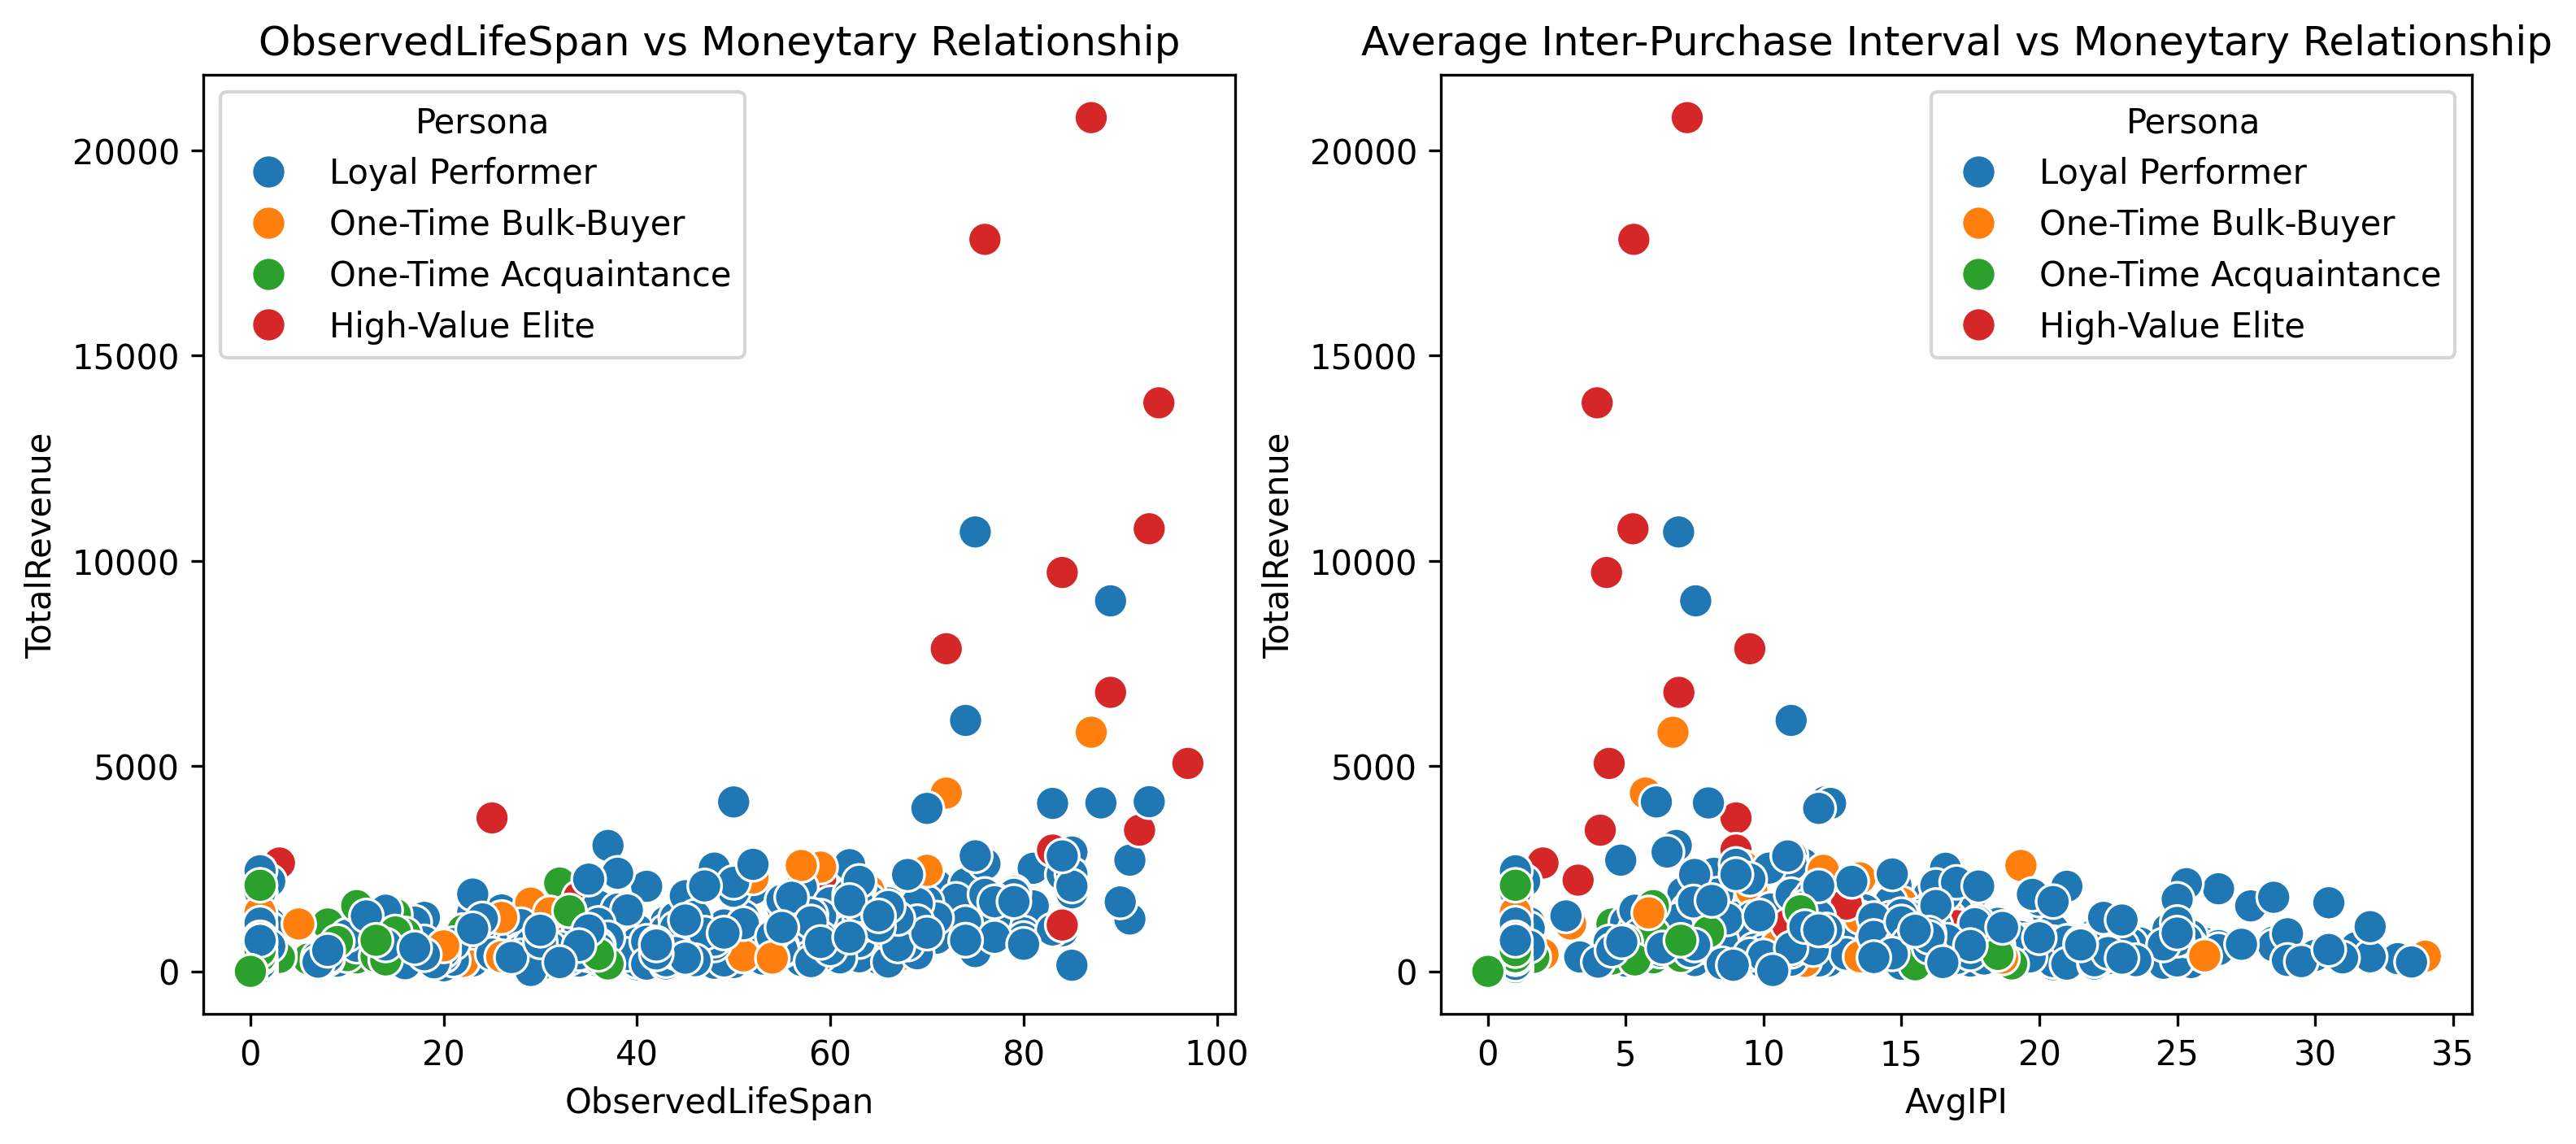

In [12]:

fig, (ax1, ax2) = plt.subplots(1,2, dpi = 300, figsize = (12,5))
sns.scatterplot(data = merged_df, x = "ObservedLifeSpan", y = "TotalRevenue", hue = "Persona", ax = ax1, s = 100)
ax1.set_title("ObservedLifeSpan vs Moneytary Relationship")
ax1.set_ylabel("TotalRevenue")

sns.scatterplot(data = merged_df, x = "AvgIPI", y = "TotalRevenue", hue = "Persona", ax = ax2, s = 100)
ax2.set_title("Average Inter-Purchase Interval vs Moneytary Relationship")
ax2.set_ylabel("TotalRevenue")

plt.show()

The highest revenue contributors, as displayed above, registered the highest `ObservedLifeSpan`, and lowest `InterPurchaseInterval`, with the majority being the `High-Value Elite`, exhibiting similar behaviour to their 60-day observation period.